<a href="https://colab.research.google.com/github/ArifaJannat2497/Nature_Sustainability_GEE_IPYNB/blob/main/Boro_Sustainability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from rasterio.plot import show
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
# ==========================================
# 0. MOUNT GOOGLE DRIVE
# ==========================================
from google.colab import drive

drive.mount('/content/drive')

# Updated Google Drive folder path
drive_path = '/content/drive/MyDrive/Nature_sustain_boro/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ==========================================
# 1. LOAD AND PREPARE THE PANEL DATASET
# ==========================================
csv_file = drive_path + 'Landsat_MultiYear_TimeSeries_2001_2025.csv'
df = pd.read_csv(csv_file)

print('--- Dataset Info ---')
print(df.info())

# Clean and sort panel data
df = df.sort_values(by=['District', 'BoroYear']).reset_index(drop=True)
df = df.dropna(subset=['Integrated_NDVI', 'Mean_LST'])

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   system:index     100 non-null    object 
 1   BoroYear         100 non-null    float64
 2   District         100 non-null    object 
 3   Integrated_NDVI  100 non-null    float64
 4   Max_NIRv         100 non-null    float64
 5   Mean_LST         100 non-null    float64
 6   .geo             100 non-null    object 
dtypes: float64(4), object(3)
memory usage: 5.6+ KB
None


In [ ]:
import pandas as pd
import numpy as np

from google.colab import drive

# =========================================================
# 1. Mount Google Drive
# =========================================================

drive.mount('/content/drive')

drive_path = '/content/drive/MyDrive/Nature_sustain_boro/'


# =========================================================
# 2. Load CSV files
# =========================================================

df_landsat = pd.read_csv(
    drive_path + 'Landsat_MultiYear_TimeSeries_2001_2025.csv'
)

df_water = pd.read_csv(
    drive_path + 'Boro_Water_TimeSeries_2001_2025.csv'
)


# =========================================================
# 3. Check input data
# =========================================================

print("Landsat shape:", df_landsat.shape)
print("Water shape:", df_water.shape)

print("\nLandsat columns:")
print(df_landsat.columns.tolist())

print("\nWater columns:")
print(df_water.columns.tolist())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Landsat shape: (100, 7)
Water shape: (100, 8)

Landsat columns:
['system:index', 'BoroYear', 'District', 'Integrated_NDVI', 'Max_NIRv', 'Mean_LST', '.geo']

Water columns:
['system:index', 'BoroET_ERA5Land', 'BoroPET_ERA5Land', 'BoroRain_mm', 'BoroYear', 'District', 'ET_minus_Rain', '.geo']


In [ ]:
# =========================================================
# 4. Correct PET sign
# =========================================================

df_water["BoroPET_ERA5Land"] = (
    -df_water["BoroPET_ERA5Land"]
)


# =========================================================
# 5. Recalculate derived water variables
# =========================================================

df_water["ET_minus_Rain"] = (
    df_water["BoroET_ERA5Land"]
    - df_water["BoroRain_mm"]
)

df_water["ET_PET_ratio"] = np.where(
    df_water["BoroPET_ERA5Land"] > 0,
    df_water["BoroET_ERA5Land"]
    / df_water["BoroPET_ERA5Land"],
    np.nan
)


# =========================================================
# 6. Validate PET correction
# =========================================================

print("\nNegative PET values:")
print(
    (df_water["BoroPET_ERA5Land"] < 0).sum()
)

print("\nPET summary:")
print(
    df_water["BoroPET_ERA5Land"].describe()
)

print("\nET/PET summary:")
print(
    df_water["ET_PET_ratio"].describe()
)


Negative PET values:
0

PET summary:
count     100.000000
mean     1284.460606
std        89.793156
min      1095.132824
25%      1218.982814
50%      1282.268425
75%      1364.417412
max      1498.350273
Name: BoroPET_ERA5Land, dtype: float64

ET/PET summary:
count    100.000000
mean       0.376319
std        0.047901
min        0.274171
25%        0.342932
50%        0.382091
75%        0.404664
max        0.484327
Name: ET_PET_ratio, dtype: float64


In [ ]:
# =========================================================
# 7. Standardize merge keys
# =========================================================

df_landsat["BoroYear"] = (
    df_landsat["BoroYear"].astype(int)
)

df_water["BoroYear"] = (
    df_water["BoroYear"].astype(int)
)

df_landsat["District"] = (
    df_landsat["District"].astype(str).str.strip()
)

df_water["District"] = (
    df_water["District"].astype(str).str.strip()
)


# =========================================================
# 8. Merge Landsat + water
# =========================================================

df = df_landsat.merge(
    df_water,
    on=["District", "BoroYear"],
    how="inner",
    validate="one_to_one"
)


# =========================================================
# 9. Inspect merged dataset
# =========================================================

print("\nMerged shape:", df.shape)

print("\nDistricts:")
print(df["District"].unique())

print("\nYear range:")
print(
    df["BoroYear"].min(),
    "to",
    df["BoroYear"].max()
)

print("\nMissing values:")
print(df.isna().sum())


Merged shape: (100, 14)

Districts:
['Mymensingh' 'Rajshahi' 'Rangpur' 'Sunamganj']

Year range:
2001 to 2025

Missing values:
system:index_x      0
BoroYear            0
District            0
Integrated_NDVI     0
Max_NIRv            0
Mean_LST            0
.geo_x              0
system:index_y      0
BoroET_ERA5Land     0
BoroPET_ERA5Land    0
BoroRain_mm         0
ET_minus_Rain       0
.geo_y              0
ET_PET_ratio        0
dtype: int64


In [ ]:
# =========================================================
# 10. Save integrated panel
# =========================================================

output_file = (
    drive_path +
    "Boro_Integrated_Panel_2001_2025.csv"
)

df.to_csv(
    output_file,
    index=False
)

print("\nSaved:")
print(output_file)


Saved:
/content/drive/MyDrive/Nature_sustain_boro/Boro_Integrated_Panel_2001_2025.csv


In [ ]:
required = [
    "District",
    "BoroYear",
    "Integrated_NDVI",
    "Max_NIRv",
    "Mean_LST",
    "BoroET_ERA5Land",
    "BoroPET_ERA5Land",
    "BoroRain_mm",
    "ET_minus_Rain",
    "ET_PET_ratio"
]

missing = [
    col for col in required
    if col not in df.columns
]

print("Missing required columns:", missing)

Missing required columns: []


In [ ]:
print(
    df[
        [
            "Integrated_NDVI",
            "Max_NIRv",
            "Mean_LST",
            "BoroET_ERA5Land",
            "BoroPET_ERA5Land",
            "BoroRain_mm",
            "ET_minus_Rain",
            "ET_PET_ratio"
        ]
    ].describe().T
)

                  count         mean         std          min          25%  \
Integrated_NDVI   100.0     2.647451    0.564691     1.185801     2.268066   
Max_NIRv          100.0     0.182816    0.022730     0.130453     0.168778   
Mean_LST          100.0   300.710537    1.533602   294.273996   299.754110   
BoroET_ERA5Land   100.0   480.216934   43.598097   377.608849   450.017842   
BoroPET_ERA5Land  100.0  1284.460606   89.793156  1095.132824  1218.982814   
BoroRain_mm       100.0   596.633513  345.072754   171.462187   309.141941   
ET_minus_Rain     100.0  -116.416579  329.572113  -958.355326  -260.424851   
ET_PET_ratio      100.0     0.376319    0.047901     0.274171     0.342932   

                          50%          75%          max  
Integrated_NDVI      2.584132     3.117554     3.751299  
Max_NIRv             0.186242     0.199977     0.236219  
Mean_LST           300.878866   301.662168   303.657041  
BoroET_ERA5Land    480.641237   507.304402   594.109689  
BoroPET

In [ ]:
print(
    df[
        [
            "Integrated_NDVI",
            "Max_NIRv",
            "Mean_LST",
            "BoroET_ERA5Land",
            "BoroPET_ERA5Land",
            "BoroRain_mm",
            "ET_minus_Rain",
            "ET_PET_ratio"
        ]
    ].corr().round(3)
)

                  Integrated_NDVI  Max_NIRv  Mean_LST  BoroET_ERA5Land  \
Integrated_NDVI             1.000     0.771     0.062           -0.009   
Max_NIRv                    0.771     1.000    -0.250            0.149   
Mean_LST                    0.062    -0.250     1.000           -0.170   
BoroET_ERA5Land            -0.009     0.149    -0.170            1.000   
BoroPET_ERA5Land           -0.077    -0.241     0.355           -0.279   
BoroRain_mm                -0.245     0.215    -0.416            0.411   
ET_minus_Rain               0.255    -0.205     0.414           -0.298   
ET_PET_ratio                0.031     0.220    -0.298            0.849   

                  BoroPET_ERA5Land  BoroRain_mm  ET_minus_Rain  ET_PET_ratio  
Integrated_NDVI             -0.077       -0.245          0.255         0.031  
Max_NIRv                    -0.241        0.215         -0.205         0.220  
Mean_LST                     0.355       -0.416          0.414        -0.298  
BoroET_ERA5Land  

In [ ]:
# ============================================================
# LOAD FINAL INTEGRATED PANEL
# ============================================================

import pandas as pd
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

drive_path = '/content/drive/MyDrive/Nature_sustain_boro/'

# Load integrated panel
panel = pd.read_csv(
    drive_path + 'Boro_Integrated_Panel_2001_2025.csv'
)

print("Panel shape:", panel.shape)

print("\nColumns:")
print(panel.columns.tolist())

print("\nFirst 10 rows:")
display(panel.head(10))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Panel shape: (100, 14)

Columns:
['system:index_x', 'BoroYear', 'District', 'Integrated_NDVI', 'Max_NIRv', 'Mean_LST', '.geo_x', 'system:index_y', 'BoroET_ERA5Land', 'BoroPET_ERA5Land', 'BoroRain_mm', 'ET_minus_Rain', '.geo_y', 'ET_PET_ratio']

First 10 rows:


,system:index_x,BoroYear,District,Integrated_NDVI,Max_NIRv,Mean_LST,.geo_x,system:index_y,BoroET_ERA5Land,BoroPET_ERA5Land,BoroRain_mm,ET_minus_Rain,.geo_y,ET_PET_ratio
0,0_00030000000000000628,2001,Mymensingh,2.275971,0.180153,299.516040,"{""type"":""MultiPoint"",""coordinates"":[]}",0_00030000000000000628,514.826344,1278.086267,556.076297,-41.249953,"{""type"":""Polygon"",""coordinates"":[[[90.07838509...",0.402810
1,0_00030000000000000631,2001,Rajshahi,2.009369,0.130453,301.769374,"{""type"":""MultiPoint"",""coordinates"":[]}",0_00030000000000000631,429.455310,1368.703973,278.452556,151.002753,"{""type"":""Polygon"",""coordinates"":[[[88.29211378...",0.313768
2,0_0003000000000000131b,2001,Rangpur,2.009826,0.153359,300.544726,"{""type"":""MultiPoint"",""coordinates"":[]}",0_0003000000000000131b,425.973320,1312.337625,453.726790,-27.753470,"{""type"":""Polygon"",""coordinates"":[[[88.93193686...",0.324591
3,0_000300000000000005fe,2001,Sunamganj,2.352926,0.178121,299.290835,"{""type"":""MultiPoint"",""coordinates"":[]}",0_000300000000000005fe,530.196289,1272.072597,871.222746,-341.026457,"{""type"":""Polygon"",""coordinates"":[[[90.93266411...",0.416797
4,1_00030000000000000628,2002,Mymensingh,1.762845,0.135499,301.448651,"{""type"":""MultiPoint"",""coordinates"":[]}",1_00030000000000000628,491.164056,1192.957974,658.066637,-166.902581,"{""type"":""Polygon"",""coordinates"":[[[90.07838509...",0.411719
5,1_00030000000000000631,2002,Rajshahi,1.962427,0.145357,303.033094,"{""type"":""MultiPoint"",""coordinates"":[]}",1_00030000000000000631,471.067781,1220.345586,215.258455,255.809327,"{""type"":""Polygon"",""coordinates"":[[[88.29211378...",0.386012
6,1_0003000000000000131b,2002,Rangpur,2.430636,0.168391,302.231560,"{""type"":""MultiPoint"",""coordinates"":[]}",1_0003000000000000131b,453.847626,1137.868200,419.661676,34.185950,"{""type"":""Polygon"",""coordinates"":[[[88.93193686...",0.398858
7,1_000300000000000005fe,2002,Sunamganj,1.580623,0.168491,301.152118,"{""type"":""MultiPoint"",""coordinates"":[]}",1_000300000000000005fe,488.698815,1220.110261,1342.301282,-853.602467,"{""type"":""Polygon"",""coordinates"":[[[90.93266411...",0.400537
8,2_00030000000000000628,2003,Mymensingh,3.118108,0.184383,301.677985,"{""type"":""MultiPoint"",""coordinates"":[]}",2_00030000000000000628,549.212951,1210.647180,539.890831,9.322120,"{""type"":""Polygon"",""coordinates"":[[[90.07838509...",0.453652
9,2_00030000000000000631,2003,Rajshahi,1.623967,0.131720,301.374914,"{""type"":""MultiPoint"",""coordinates"":[]}",2_00030000000000000631,543.301663,1219.378042,235.696176,307.605486,"{""type"":""Polygon"",""coordinates"":[[[88.29211378...",0.445556


In [ ]:
# ============================================================
# BASIC PANEL CHECK
# ============================================================

print("Districts:")
print(panel["District"].unique())

print("\nYear range:")
print(
    panel["BoroYear"].min(),
    "to",
    panel["BoroYear"].max()
)

print("\nObservations per district:")
display(
    panel.groupby("District").size()
)

print("\nMissing values:")
display(
    panel.isna().sum().to_frame("Missing")
)

Districts:
['Mymensingh' 'Rajshahi' 'Rangpur' 'Sunamganj']

Year range:
2001 to 2025

Observations per district:


,0
District,
Mymensingh,25
Rajshahi,25
Rangpur,25
Sunamganj,25



Missing values:


,Missing
system:index_x,0
BoroYear,0
District,0
Integrated_NDVI,0
Max_NIRv,0
Mean_LST,0
.geo_x,0
system:index_y,0
BoroET_ERA5Land,0
BoroPET_ERA5Land,0


In [ ]:
# ============================================================
# WATER VARIABLE CHECK
# ============================================================

water_vars = [
    "BoroET_ERA5Land",
    "BoroPET_ERA5Land",
    "BoroRain_mm",
    "ET_minus_Rain",
    "ET_PET_ratio"
]

display(
    panel[water_vars].describe().T
)

print(
    "Negative PET:",
    (panel["BoroPET_ERA5Land"] < 0).sum()
)

print(
    "Negative ET:",
    (panel["BoroET_ERA5Land"] < 0).sum()
)

,count,mean,std,min,25%,50%,75%,max
BoroET_ERA5Land,100.0,480.216934,43.598097,377.608849,450.017842,480.641237,507.304402,594.109689
BoroPET_ERA5Land,100.0,1284.460606,89.793156,1095.132824,1218.982814,1282.268425,1364.417412,1498.350273
BoroRain_mm,100.0,596.633513,345.072754,171.462187,309.141941,515.308074,770.205882,1449.185137
ET_minus_Rain,100.0,-116.416579,329.572113,-958.355326,-260.424851,-39.209984,145.877545,307.605486
ET_PET_ratio,100.0,0.376319,0.047901,0.274171,0.342932,0.382091,0.404664,0.484327


Negative PET: 0
Negative ET: 0


In [ ]:
# ============================================================
# STEP 2 — FINAL PANEL CLEANING
# ============================================================

panel["BoroYear"] = pd.to_numeric(
    panel["BoroYear"], errors="coerce"
)

panel["District"] = (
    panel["District"]
    .astype(str)
    .str.strip()
)

# Make sure numeric variables are numeric
numeric_vars = [
    "Integrated_NDVI",
    "Max_NIRv",
    "Mean_LST",
    "BoroET_ERA5Land",
    "BoroPET_ERA5Land",
    "BoroRain_mm",
    "ET_minus_Rain",
    "ET_PET_ratio"
]

for col in numeric_vars:
    panel[col] = pd.to_numeric(
        panel[col], errors="coerce"
    )

panel = panel.sort_values(
    ["District", "BoroYear"]
).reset_index(drop=True)

print("Final panel:", panel.shape)
print("\nObservations per district:")
display(panel.groupby("District").size())

Final panel: (100, 14)

Observations per district:


,0
District,
Mymensingh,25
Rajshahi,25
Rangpur,25
Sunamganj,25


In [ ]:
# ============================================================
# STEP 3 — DESCRIPTIVE STATISTICS
# ============================================================

variables = [
    "Integrated_NDVI",
    "Max_NIRv",
    "Mean_LST",
    "BoroET_ERA5Land",
    "BoroPET_ERA5Land",
    "BoroRain_mm",
    "ET_minus_Rain",
    "ET_PET_ratio"
]

stats = panel[variables].describe().T

display(stats)

,count,mean,std,min,25%,50%,75%,max
Integrated_NDVI,100.0,2.647451,0.564691,1.185801,2.268066,2.584132,3.117554,3.751299
Max_NIRv,100.0,0.182816,0.022730,0.130453,0.168778,0.186242,0.199977,0.236219
Mean_LST,100.0,300.710537,1.533602,294.273996,299.754110,300.878866,301.662168,303.657041
BoroET_ERA5Land,100.0,480.216934,43.598097,377.608849,450.017842,480.641237,507.304402,594.109689
BoroPET_ERA5Land,100.0,1284.460606,89.793156,1095.132824,1218.982814,1282.268425,1364.417412,1498.350273
BoroRain_mm,100.0,596.633513,345.072754,171.462187,309.141941,515.308074,770.205882,1449.185137
ET_minus_Rain,100.0,-116.416579,329.572113,-958.355326,-260.424851,-39.209984,145.877545,307.605486
ET_PET_ratio,100.0,0.376319,0.047901,0.274171,0.342932,0.382091,0.404664,0.484327


In [ ]:
# ============================================================
# STEP 4 — DISTRICT CHARACTERISTICS
# ============================================================

district_summary = (
    panel
    .groupby("District")[variables]
    .mean()
    .round(3)
)

display(district_summary)

,Integrated_NDVI,Max_NIRv,Mean_LST,BoroET_ERA5Land,BoroPET_ERA5Land,BoroRain_mm,ET_minus_Rain,ET_PET_ratio
District,,,,,,,,
Mymensingh,2.949,0.190,300.558,495.089,1294.389,601.013,-105.924,0.384
Rajshahi,2.612,0.167,302.357,457.155,1329.527,243.324,213.831,0.347
Rangpur,2.747,0.188,299.905,453.338,1230.570,455.571,-2.233,0.371
Sunamganj,2.281,0.186,300.022,515.286,1283.357,1086.626,-571.340,0.403


In [ ]:
# ============================================================
# STEP 5 — DISTRICT TIME TRENDS
# ============================================================

from scipy.stats import linregress

trend_results = []

trend_variables = [
    "Integrated_NDVI",
    "Max_NIRv",
    "BoroET_ERA5Land",
    "BoroRain_mm",
    "ET_PET_ratio",
    "Mean_LST"
]

for district in panel["District"].unique():

    temp = panel[
        panel["District"] == district
    ].sort_values("BoroYear")

    for variable in trend_variables:

        result = linregress(
            temp["BoroYear"],
            temp[variable]
        )

        trend_results.append({
            "District": district,
            "Variable": variable,
            "Annual_trend": result.slope,
            "p_value": result.pvalue,
            "R_squared": result.rvalue ** 2
        })

trend_df = pd.DataFrame(trend_results)

display(
    trend_df.round(4)
)

,District,Variable,Annual_trend,p_value,R_squared
0,Mymensingh,Integrated_NDVI,0.0539,0.0000,0.5562
1,Mymensingh,Max_NIRv,0.0020,0.0000,0.5837
2,Mymensingh,BoroET_ERA5Land,-0.5607,0.5666,0.0145
3,Mymensingh,BoroRain_mm,0.3177,0.9241,0.0004
4,Mymensingh,ET_PET_ratio,-0.0007,0.5290,0.0175
5,Mymensingh,Mean_LST,-0.0133,0.6587,0.0086
6,Rajshahi,Integrated_NDVI,0.0633,0.0000,0.7787
7,Rajshahi,Max_NIRv,0.0027,0.0000,0.8202
8,Rajshahi,BoroET_ERA5Land,0.2177,0.8297,0.0021
9,Rajshahi,BoroRain_mm,3.6474,0.0208,0.2114


In [ ]:
# ============================================================
# STEP 6 — EARLY VS RECENT PERIOD
# ============================================================

early_years = panel["BoroYear"].sort_values().unique()[:5]
late_years  = panel["BoroYear"].sort_values().unique()[-5:]

print("Early period:", early_years)
print("Recent period:", late_years)

early = (
    panel[panel["BoroYear"].isin(early_years)]
    .groupby("District")[variables]
    .mean()
)

late = (
    panel[panel["BoroYear"].isin(late_years)]
    .groupby("District")[variables]
    .mean()
)

trajectory = late - early

display(
    trajectory.round(3)
)

Early period: [2001 2002 2003 2004 2005]
Recent period: [2021 2022 2023 2024 2025]


,Integrated_NDVI,Max_NIRv,Mean_LST,BoroET_ERA5Land,BoroPET_ERA5Land,BoroRain_mm,ET_minus_Rain,ET_PET_ratio
District,,,,,,,,
Mymensingh,1.020,0.037,-0.557,-7.282,75.162,-88.295,81.013,-0.027
Rajshahi,1.158,0.051,-0.847,-18.912,17.749,40.855,-59.768,-0.020
Rangpur,1.184,0.055,-0.564,-14.055,54.154,14.335,-28.390,-0.027
Sunamganj,0.543,0.026,-0.024,28.190,75.407,-250.142,278.332,-0.001


In [ ]:
# ============================================================
# STEP 7 — PERCENT CHANGE
# ============================================================

percent_change = (
    ((late - early) / early.abs()) * 100
)

display(
    percent_change.round(2)
)

,Integrated_NDVI,Max_NIRv,Mean_LST,BoroET_ERA5Land,BoroPET_ERA5Land,BoroRain_mm,ET_minus_Rain,ET_PET_ratio
District,,,,,,,,
Mymensingh,42.27,22.43,-0.19,-1.45,5.94,-14.88,89.21,-6.86
Rajshahi,55.47,36.65,-0.28,-4.04,1.35,18.86,-23.72,-5.66
Rangpur,54.02,33.78,-0.19,-3.03,4.52,3.33,-86.19,-6.96
Sunamganj,26.97,15.18,-0.01,5.48,6.02,-21.51,42.92,-0.17


In [ ]:
# ============================================================
# STEP 8 — FOOD–WATER TRAJECTORY
# ============================================================

trajectory_class = trajectory[
    [
        "Integrated_NDVI",
        "BoroET_ERA5Land"
    ]
].copy()

def classify(row):

    food_change = row["Integrated_NDVI"]
    water_change = row["BoroET_ERA5Land"]

    if food_change > 0 and water_change < 0:
        return "Higher productivity proxy / lower ET"

    elif food_change > 0 and water_change > 0:
        return "Higher productivity proxy / higher ET"

    elif food_change < 0 and water_change > 0:
        return "Lower productivity proxy / higher ET"

    elif food_change < 0 and water_change < 0:
        return "Lower productivity proxy / lower ET"

    else:
        return "Near-zero change"

trajectory_class["Trajectory"] = (
    trajectory_class.apply(classify, axis=1)
)

display(trajectory_class)

,Integrated_NDVI,BoroET_ERA5Land,Trajectory
District,,,
Mymensingh,1.019676,-7.282091,Higher productivity proxy / lower ET
Rajshahi,1.158349,-18.912432,Higher productivity proxy / lower ET
Rangpur,1.184435,-14.054693,Higher productivity proxy / lower ET
Sunamganj,0.543005,28.189739,Higher productivity proxy / higher ET


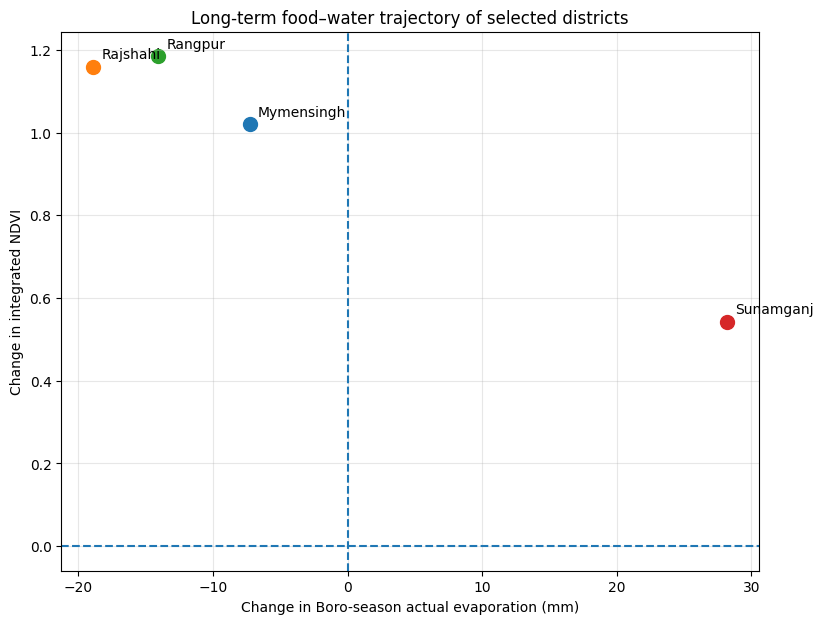

In [ ]:
# ============================================================
# STEP 9 — PRODUCTIVITY VS WATER CHANGE
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 7))

for district in trajectory.index:

    x = trajectory.loc[
        district, "BoroET_ERA5Land"
    ]

    y = trajectory.loc[
        district, "Integrated_NDVI"
    ]

    plt.scatter(x, y, s=100)

    plt.annotate(
        district,
        (x, y),
        xytext=(6, 6),
        textcoords="offset points"
    )

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")

plt.xlabel(
    "Change in Boro-season actual evaporation (mm)"
)

plt.ylabel(
    "Change in integrated NDVI"
)

plt.title(
    "Long-term food–water trajectory of selected districts"
)

plt.grid(alpha=0.3)
plt.show()

In [ ]:
# ============================================================
# STEP 10 — SAVE ANALYSIS OUTPUTS
# ============================================================

trajectory.to_csv(
    drive_path + "Boro_Trajectory_Changes.csv"
)

percent_change.to_csv(
    drive_path + "Boro_Trajectory_Percent_Changes.csv"
)

trend_df.to_csv(
    drive_path + "Boro_District_Trends.csv",
    index=False
)

trajectory_class.to_csv(
    drive_path + "Boro_Food_Water_Trajectories.csv"
)

print("Analysis tables saved to Google Drive.")

Analysis tables saved to Google Drive.


In [ ]:
!pip -q install linearmodels

In [ ]:
# ============================================================
# STEP 11 — PREPARE PANEL FOR TWFE
# ============================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm

from linearmodels.panel import PanelOLS

# Make sure panel is sorted
panel = panel.sort_values(
    ["District", "BoroYear"]
).copy()

# Set panel index
panel_indexed = panel.set_index(
    ["District", "BoroYear"]
)

print(panel_indexed.shape)
display(panel_indexed.head())

(100, 12)


system:index_x  Integrated_NDVI  Max_NIRv  \
District   BoroYear                                                      
Mymensingh 2001      0_00030000000000000628         2.275971  0.180153   
           2002      1_00030000000000000628         1.762845  0.135499   
           2003      2_00030000000000000628         3.118108  0.184383   
           2004      3_00030000000000000628         2.292629  0.159296   
           2005      4_00030000000000000628         2.611129  0.175955   

                       Mean_LST                                  .geo_x  \
District   BoroYear                                                       
Mymensingh 2001      299.516040  {"type":"MultiPoint","coordinates":[]}   
           2002      301.448651  {"type":"MultiPoint","coordinates":[]}   
           2003      301.677985  {"type":"MultiPoint","coordinates":[]}   
           2004      299.936360  {"type":"MultiPoint","coordinates":[]}   
           2005      299.596393  {"type":"MultiPoint","coordinates":[]}   

                             system:index_y  BoroET_ERA5Land  \
District   BoroYear                                            
Mymensingh 2001      0_00030000000000000628       514.826344   
           2002      1_00030000000000000628       491.164056   
           2003      2_00030000000000000628       549.212951   
           2004      3_00030000000000000628       484.392511   
           2005      4_00030000000000000628       473.847381   

                     BoroPET_ERA5Land  BoroRain_mm  ET_minus_Rain  \
District   BoroYear                                                 
Mymensingh 2001           1278.086267   556.076297     -41.249953   
           2002           1192.957974   658.066637    -166.902581   
           2003           1210.647180   539.890831       9.322120   
           2004           1327.816129   614.106548    -129.714037   
           2005           1316.147889   599.369065    -125.521683   

                                                                .geo_y  \
District   BoroYear                                                      
Mymensingh 2001      {"type":"Polygon","coordinates":[[[90.07838509...   
           2002      {"type":"Polygon","coordinates":[[[90.07838509...   
           2003      {"type":"Polygon","coordinates":[[[90.07838509...   
           2004      {"type":"Polygon","coordinates":[[[90.07838509...   
           2005      {"type":"Polygon","coordinates":[[[90.07838509...   

                     ET_PET_ratio  
District   BoroYear                
Mymensingh 2001          0.402810  
           2002          0.411719  
           2003          0.453652  
           2004          0.364804  
           2005          0.360026

In [ ]:
# ============================================================
# MODEL 1 — TWO-WAY FIXED EFFECTS
# ============================================================

y = panel_indexed["Integrated_NDVI"]

X = panel_indexed[
    [
        "BoroET_ERA5Land",
        "BoroRain_mm",
        "Mean_LST"
    ]
]

X = sm.add_constant(X)

model1 = PanelOLS(
    y,
    X,
    entity_effects=True,
    time_effects=True,
    drop_absorbed=True
)

results1 = model1.fit(
    cov_type="clustered",
    cluster_entity=True
)

print(results1.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:        Integrated_NDVI   R-squared:                        0.0463
Estimator:                   PanelOLS   R-squared (Between):              0.1666
No. Observations:                 100   R-squared (Within):              -0.0205
Date:                Sat, Sep 26 2026   R-squared (Overall):              0.0145
Time:                        12:04:46   Log-likelihood                   -6.5617
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1.1168
Entities:                           4   P-value                           0.3483
Avg Obs:                       25.000   Distribution:                    F(3,69)
Min Obs:                       25.000                                           
Max Obs:                       25.000   F-statistic (robust):             4.7787
                            

In [ ]:
# ============================================================
# MODEL 2 — WATER-BALANCE PRESSURE
# ============================================================

y = panel_indexed["Integrated_NDVI"]

X = panel_indexed[
    [
        "ET_minus_Rain",
        "Mean_LST"
    ]
]

X = sm.add_constant(X)

model2 = PanelOLS(
    y,
    X,
    entity_effects=True,
    time_effects=True,
    drop_absorbed=True
)

results2 = model2.fit(
    cov_type="clustered",
    cluster_entity=True
)

print(results2.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:        Integrated_NDVI   R-squared:                        0.0403
Estimator:                   PanelOLS   R-squared (Between):              0.1034
No. Observations:                 100   R-squared (Within):               0.0006
Date:                Sat, Sep 26 2026   R-squared (Overall):              0.0199
Time:                        12:04:46   Log-likelihood                   -6.8740
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1.4711
Entities:                           4   P-value                           0.2367
Avg Obs:                       25.000   Distribution:                    F(2,70)
Min Obs:                       25.000                                           
Max Obs:                       25.000   F-statistic (robust):             4.6741
                            

In [ ]:
# ============================================================
# MODEL 3 — EVAPORATIVE STRESS INDICATOR
# ============================================================

y = panel_indexed["Integrated_NDVI"]

X = panel_indexed[
    [
        "ET_PET_ratio",
        "BoroRain_mm",
        "Mean_LST"
    ]
]

X = sm.add_constant(X)

model3 = PanelOLS(
    y,
    X,
    entity_effects=True,
    time_effects=True,
    drop_absorbed=True
)

results3 = model3.fit(
    cov_type="clustered",
    cluster_entity=True
)

print(results3.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:        Integrated_NDVI   R-squared:                        0.0420
Estimator:                   PanelOLS   R-squared (Between):              0.1367
No. Observations:                 100   R-squared (Within):              -0.0028
Date:                Sat, Sep 26 2026   R-squared (Overall):              0.0233
Time:                        12:04:46   Log-likelihood                   -6.7862
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1.0088
Entities:                           4   P-value                           0.3942
Avg Obs:                       25.000   Distribution:                    F(3,69)
Min Obs:                       25.000                                           
Max Obs:                       25.000   F-statistic (robust):             3.3573
                            

In [ ]:
# ============================================================
# MODEL 4 — ROBUSTNESS USING MAX NIRv
# ============================================================

y = panel_indexed["Max_NIRv"]

X = panel_indexed[
    [
        "BoroET_ERA5Land",
        "BoroRain_mm",
        "Mean_LST"
    ]
]

X = sm.add_constant(X)

model4 = PanelOLS(
    y,
    X,
    entity_effects=True,
    time_effects=True,
    drop_absorbed=True
)

results4 = model4.fit(
    cov_type="clustered",
    cluster_entity=True
)

print(results4.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:               Max_NIRv   R-squared:                        0.0150
Estimator:                   PanelOLS   R-squared (Between):             -0.4366
No. Observations:                 100   R-squared (Within):              -0.0085
Date:                Sat, Sep 26 2026   R-squared (Overall):             -0.0784
Time:                        12:04:46   Log-likelihood                    321.11
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      0.3511
Entities:                           4   P-value                           0.7885
Avg Obs:                       25.000   Distribution:                    F(3,69)
Min Obs:                       25.000                                           
Max Obs:                       25.000   F-statistic (robust):             5.3243
                            

In [ ]:
# ============================================================
# MODEL COMPARISON
# ============================================================

from linearmodels.panel import compare

comparison = compare({
    "TWFE-NDVI": results1,
    "TWFE-WaterBalance": results2,
    "TWFE-ETPET": results3,
    "TWFE-NIRv": results4
})

print(comparison)

                                         Model Comparison                                         
                                  TWFE-NDVI   TWFE-WaterBalance          TWFE-ETPET      TWFE-NIRv
--------------------------------------------------------------------------------------------------
Dep. Variable               Integrated_NDVI     Integrated_NDVI     Integrated_NDVI       Max_NIRv
Estimator                          PanelOLS            PanelOLS            PanelOLS       PanelOLS
No. Observations                        100                 100                 100            100
Cov. Est.                         Clustered           Clustered           Clustered      Clustered
R-squared                            0.0463              0.0403              0.0420         0.0150
R-Squared (Within)                  -0.0205              0.0006             -0.0028        -0.0085
R-Squared (Between)                  0.1666              0.1034              0.1367        -0.4366
R-Squared 

In [ ]:
# ============================================================
# CLEAN REGRESSION TABLE
# ============================================================

def extract_results(result, model_name):

    table = pd.DataFrame({
        "Coefficient": result.params,
        "Std_Error": result.std_errors,
        "t_stat": result.tstats,
        "p_value": result.pvalues
    })

    table["Model"] = model_name

    return table.reset_index().rename(
        columns={"index": "Variable"}
    )


reg_table = pd.concat([
    extract_results(results1, "TWFE-NDVI"),
    extract_results(results2, "TWFE-WaterBalance"),
    extract_results(results3, "TWFE-ETPET"),
    extract_results(results4, "TWFE-NIRv")
])

display(
    reg_table.round(4)
)

,Variable,Coefficient,Std_Error,t_stat,p_value,Model
0,const,-12.6871,11.9230,-1.0641,0.2910,TWFE-NDVI
1,BoroET_ERA5Land,-0.0009,0.0010,-0.8758,0.3842,TWFE-NDVI
2,BoroRain_mm,-0.0002,0.0002,-1.0115,0.3153,TWFE-NDVI
3,Mean_LST,0.0529,0.0386,1.3699,0.1751,TWFE-NDVI
0,const,-14.6414,10.6601,-1.3735,0.1740,TWFE-WaterBalance
1,ET_minus_Rain,0.0001,0.0002,0.7453,0.4586,TWFE-WaterBalance
2,Mean_LST,0.0575,0.0354,1.6258,0.1085,TWFE-WaterBalance
0,const,-14.0601,11.7521,-1.1964,0.2356,TWFE-ETPET
1,ET_PET_ratio,-0.0360,0.7765,-0.0463,0.9632,TWFE-ETPET
2,BoroRain_mm,-0.0002,0.0002,-0.8427,0.4023,TWFE-ETPET


In [ ]:
reg_table.to_csv(
    drive_path + "TWFE_Regression_Results.csv",
    index=False
)

print("Saved:", drive_path + "TWFE_Regression_Results.csv")

Saved: /content/drive/MyDrive/Nature_sustain_boro/TWFE_Regression_Results.csv


In [ ]:
# ============================================================
# DRISCOLL-KRAAY SENSITIVITY CHECK
# ============================================================

dk_results1 = model1.fit(
    cov_type="kernel",
    kernel="bartlett"
)

print(dk_results1.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:        Integrated_NDVI   R-squared:                        0.0463
Estimator:                   PanelOLS   R-squared (Between):              0.1666
No. Observations:                 100   R-squared (Within):              -0.0205
Date:                Sat, Sep 26 2026   R-squared (Overall):              0.0145
Time:                        12:04:47   Log-likelihood                   -6.5617
Cov. Estimator:        Driscoll-Kraay                                           
                                        F-statistic:                      1.1168
Entities:                           4   P-value                           0.3483
Avg Obs:                       25.000   Distribution:                    F(3,69)
Min Obs:                       25.000                                           
Max Obs:                       25.000   F-statistic (robust):             0.2462
                            

In [ ]:
print(results1.summary)
print(results2.summary)
print(results3.summary)
print(results4.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:        Integrated_NDVI   R-squared:                        0.0463
Estimator:                   PanelOLS   R-squared (Between):              0.1666
No. Observations:                 100   R-squared (Within):              -0.0205
Date:                Sat, Sep 26 2026   R-squared (Overall):              0.0145
Time:                        12:04:46   Log-likelihood                   -6.5617
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1.1168
Entities:                           4   P-value                           0.3483
Avg Obs:                       25.000   Distribution:                    F(3,69)
Min Obs:                       25.000                                           
Max Obs:                       25.000   F-statistic (robust):             4.7787
                            

In [ ]:
# ============================================================
# FIGURE GENERATION — Boro food-water analysis
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Load integrated panel
# ------------------------------------------------------------

drive_path = '/content/drive/MyDrive/Nature_sustain_boro/'

panel = pd.read_csv(
    drive_path + 'Boro_Integrated_Panel_2001_2025.csv'
)

panel["BoroYear"] = pd.to_numeric(
    panel["BoroYear"],
    errors="coerce"
)

panel["District"] = (
    panel["District"].astype(str).str.strip()
)

panel = panel.sort_values(
    ["District", "BoroYear"]
)

districts = panel["District"].unique()

print("Loaded:", panel.shape)
print("Districts:", districts)

Loaded: (100, 14)
Districts: ['Mymensingh' 'Rajshahi' 'Rangpur' 'Sunamganj']


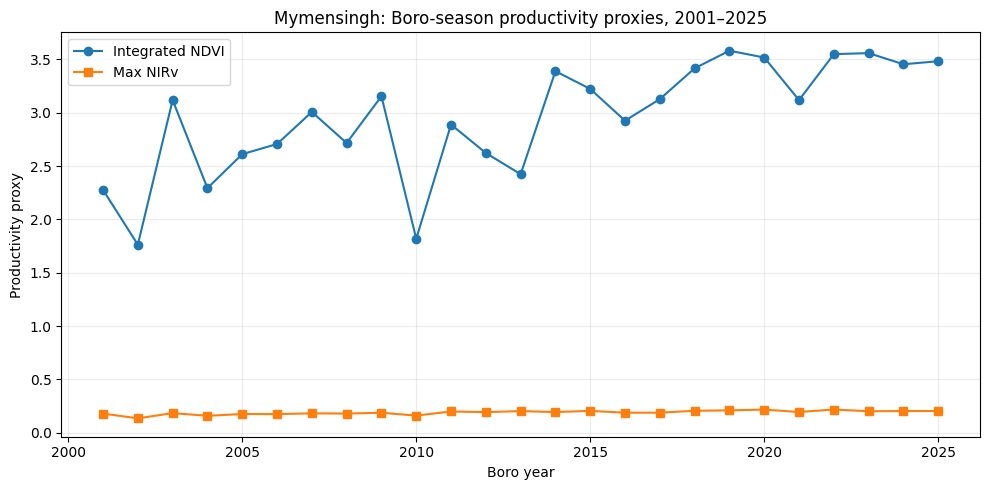

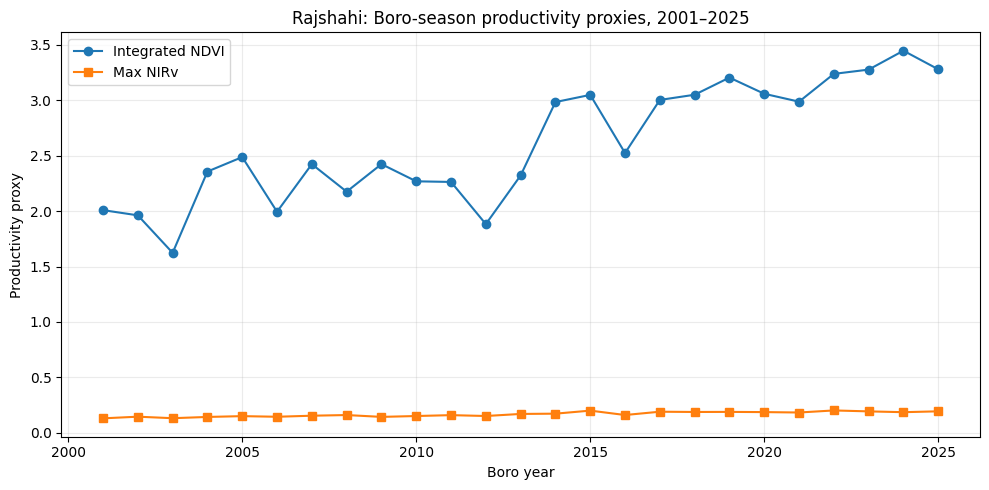

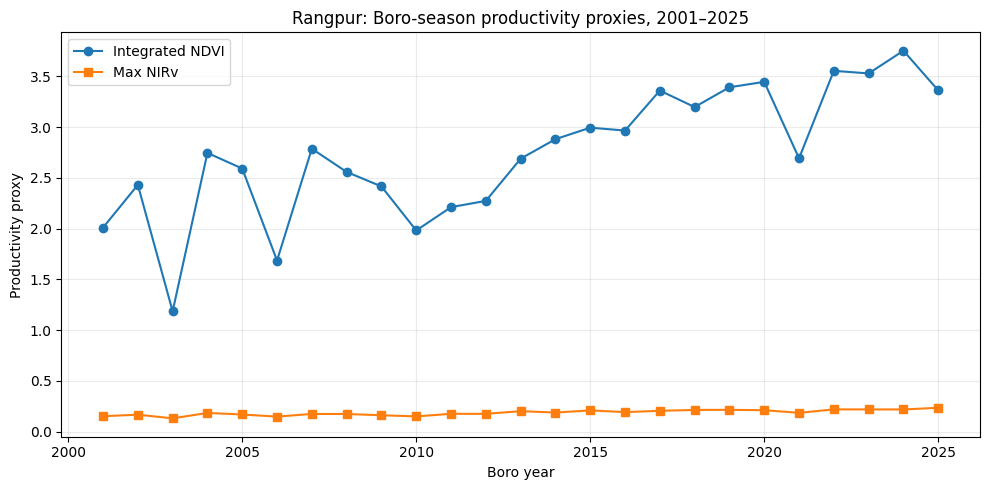

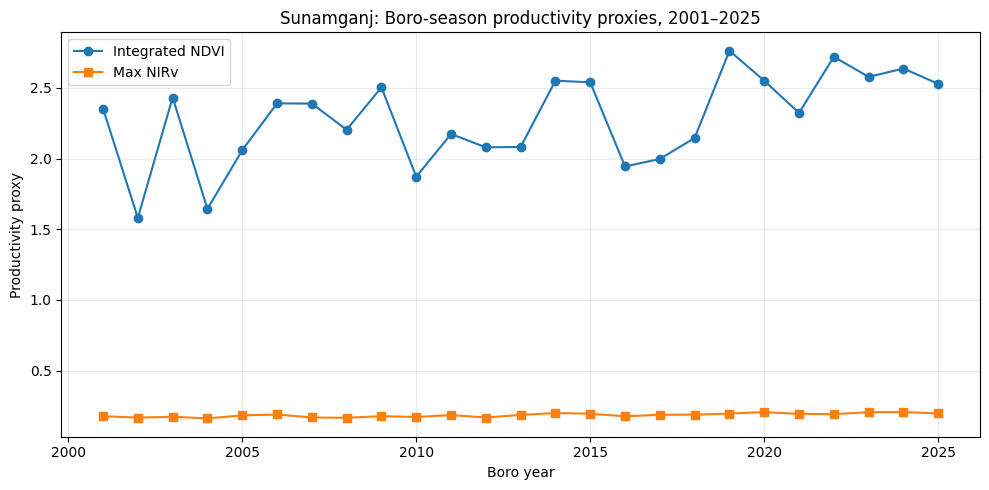

In [ ]:
# ============================================================
# FIGURE 1 — PRODUCTIVITY TRAJECTORIES
# ============================================================

for district in districts:

    temp = panel[
        panel["District"] == district
    ].sort_values("BoroYear")

    plt.figure(figsize=(10, 5))

    plt.plot(
        temp["BoroYear"],
        temp["Integrated_NDVI"],
        marker="o",
        label="Integrated NDVI"
    )

    plt.plot(
        temp["BoroYear"],
        temp["Max_NIRv"],
        marker="s",
        label="Max NIRv"
    )

    plt.xlabel("Boro year")
    plt.ylabel("Productivity proxy")
    plt.title(
        f"{district}: Boro-season productivity proxies, 2001–2025"
    )

    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()

    filename = (
        drive_path +
        f"Figure1_Productivity_{district}.png"
    )

    plt.savefig(
        filename,
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()

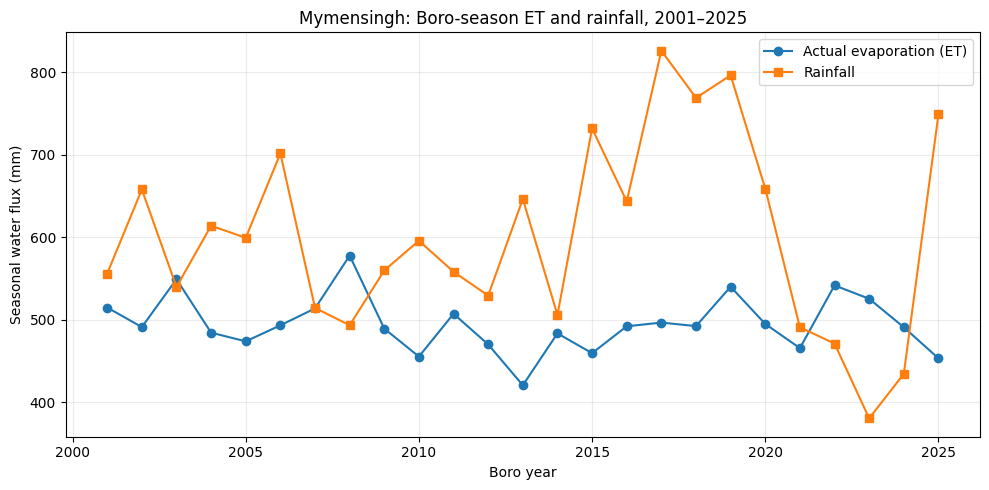

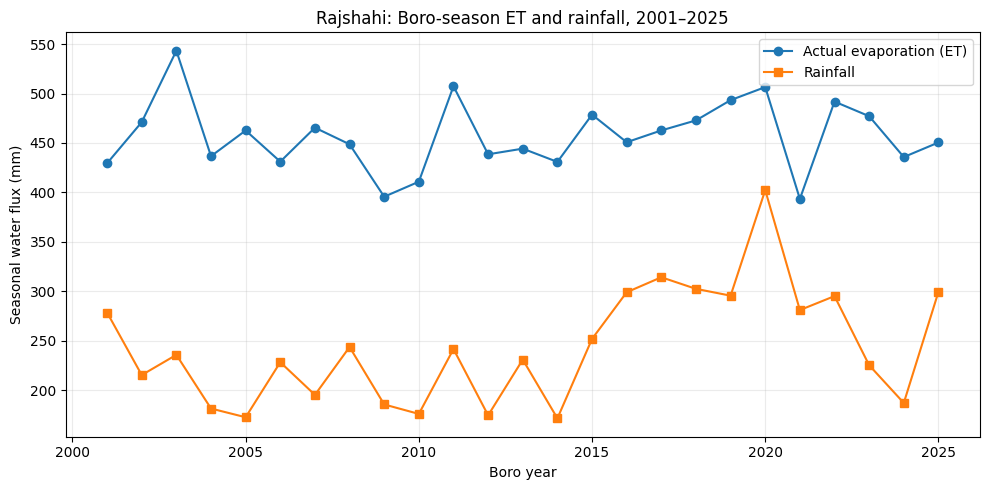

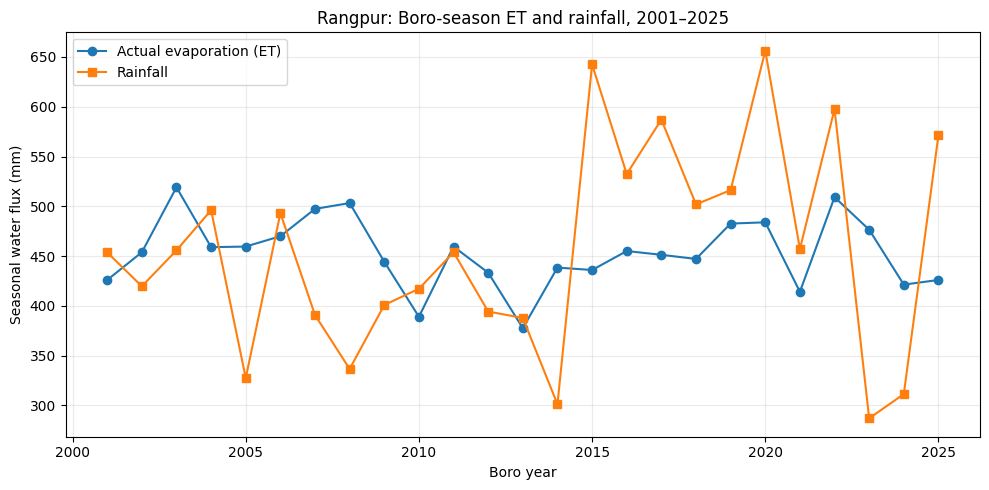

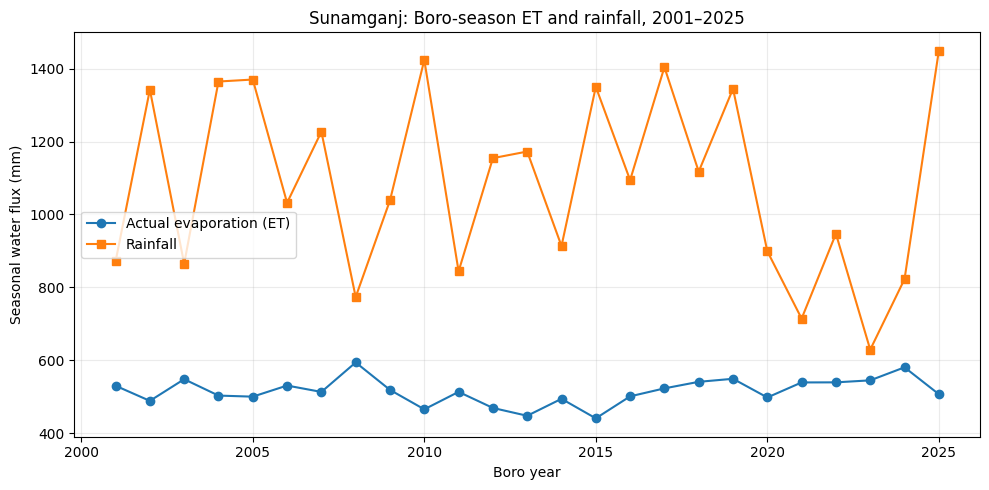

In [ ]:
# ============================================================
# FIGURE 2 — WATER TRAJECTORIES
# ============================================================

for district in districts:

    temp = panel[
        panel["District"] == district
    ].sort_values("BoroYear")

    plt.figure(figsize=(10, 5))

    plt.plot(
        temp["BoroYear"],
        temp["BoroET_ERA5Land"],
        marker="o",
        label="Actual evaporation (ET)"
    )

    plt.plot(
        temp["BoroYear"],
        temp["BoroRain_mm"],
        marker="s",
        label="Rainfall"
    )

    plt.xlabel("Boro year")
    plt.ylabel("Seasonal water flux (mm)")
    plt.title(
        f"{district}: Boro-season ET and rainfall, 2001–2025"
    )

    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()

    filename = (
        drive_path +
        f"Figure2_Water_{district}.png"
    )

    plt.savefig(
        filename,
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()

In [ ]:
# ============================================================
# FOUR-QUADRANT TRAJECTORY DATA
# ============================================================

years = sorted(panel["BoroYear"].unique())

early_years = years[:5]
recent_years = years[-5:]

print("Early period:", early_years)
print("Recent period:", recent_years)

early = (
    panel[
        panel["BoroYear"].isin(early_years)
    ]
    .groupby("District")
    .agg({
        "Integrated_NDVI": "mean",
        "BoroET_ERA5Land": "mean"
    })
)

recent = (
    panel[
        panel["BoroYear"].isin(recent_years)
    ]
    .groupby("District")
    .agg({
        "Integrated_NDVI": "mean",
        "BoroET_ERA5Land": "mean"
    })
)

trajectory = recent - early

trajectory = trajectory.rename(columns={
    "Integrated_NDVI": "Delta_NDVI",
    "BoroET_ERA5Land": "Delta_ET"
})

print("\nTrajectory changes:")
display(trajectory)

Early period: [np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005)]
Recent period: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Trajectory changes:


,Delta_NDVI,Delta_ET
District,,
Mymensingh,1.019676,-7.282091
Rajshahi,1.158349,-18.912432
Rangpur,1.184435,-14.054693
Sunamganj,0.543005,28.189739


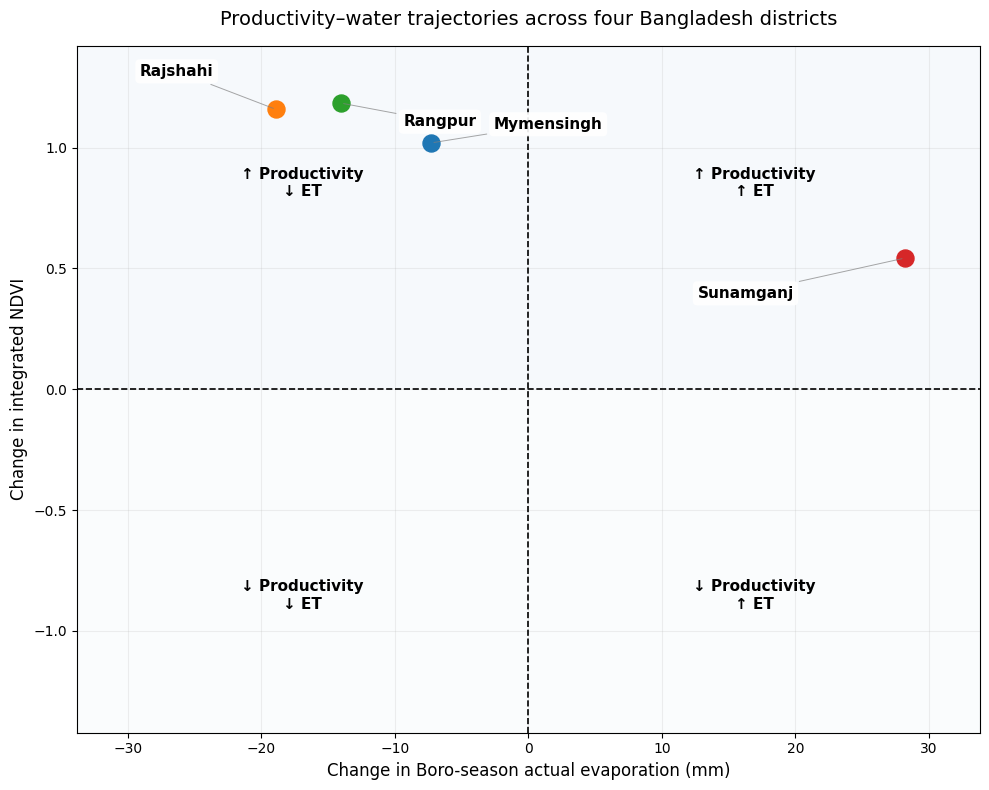

Figure saved to:
/content/drive/MyDrive/Nature_sustain_boro/Figure3_Productivity_Water_Trajectories.png


In [ ]:
# ============================================================
# FIGURE 3 — FOUR-QUADRANT PRODUCTIVITY–WATER TRAJECTORY
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 8))

# ------------------------------------------------------------
# 1. Symmetric limits around zero
# ------------------------------------------------------------

max_x = max(
    abs(trajectory["Delta_ET"].min()),
    abs(trajectory["Delta_ET"].max())
)

max_y = max(
    abs(trajectory["Delta_NDVI"].min()),
    abs(trajectory["Delta_NDVI"].max())
)

x_lim = max_x * 1.20
y_lim = max_y * 1.20

ax.set_xlim(-x_lim, x_lim)
ax.set_ylim(-y_lim, y_lim)

# ------------------------------------------------------------
# 2. Four quadrant backgrounds
# ------------------------------------------------------------

ax.axvspan(
    -x_lim, 0,
    ymin=0.5, ymax=1,
    alpha=0.04,
    zorder=0
)

ax.axvspan(
    0, x_lim,
    ymin=0.5, ymax=1,
    alpha=0.04,
    zorder=0
)

ax.axvspan(
    -x_lim, 0,
    ymin=0, ymax=0.5,
    alpha=0.02,
    zorder=0
)

ax.axvspan(
    0, x_lim,
    ymin=0, ymax=0.5,
    alpha=0.02,
    zorder=0
)

# ------------------------------------------------------------
# 3. Zero reference lines
# ------------------------------------------------------------

ax.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.2,
    zorder=2
)

ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.2,
    zorder=2
)

# ------------------------------------------------------------
# 4. District label positions
# ------------------------------------------------------------
# These are deliberately separated from the colored points.

label_offsets = {
    "Rajshahi":   (-45, 22),   # left and above orange
    "Rangpur":    (45, -8),    # FARTHER right of green
    "Mymensingh": (45, 8),     # FARTHER right of blue
    "Sunamganj":  (-80, -20)    # left and below red
}

# ------------------------------------------------------------
# 5. Plot districts
# ------------------------------------------------------------

for district in trajectory.index:

    x = trajectory.loc[district, "Delta_ET"]
    y = trajectory.loc[district, "Delta_NDVI"]

    # Plot point
    ax.scatter(
        x,
        y,
        s=150,
        zorder=5
    )

    # Get label position
    dx, dy = label_offsets.get(
        district,
        (10, 10)
    )

    # District name
    ax.annotate(
        district,
        xy=(x, y),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=11,
        fontweight="bold",
        ha="left" if dx >= 0 else "right",
        va="bottom" if dy >= 0 else "top",

        # White box prevents overlap with grid/point
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor="none",
            alpha=0.9
        ),

        # Thin connector
        arrowprops=dict(
            arrowstyle="-",
            linewidth=0.7,
            color="gray",
            alpha=0.7
        ),

        zorder=6
    )

# ------------------------------------------------------------
# 6. Quadrant labels — CENTER of each quadrant
# ------------------------------------------------------------

# Upper-left quadrant
ax.text(
    -x_lim * 0.50,
    y_lim * 0.60,
    "↑ Productivity\n↓ ET",
    ha="center",
    va="center",
    fontsize=11,
    fontweight="bold",
    zorder=3
)

# Upper-right quadrant
ax.text(
    x_lim * 0.50,
    y_lim * 0.60,
    "↑ Productivity\n↑ ET",
    ha="center",
    va="center",
    fontsize=11,
    fontweight="bold",
    zorder=3
)

# Lower-left quadrant
ax.text(
    -x_lim * 0.50,
    -y_lim * 0.60,
    "↓ Productivity\n↓ ET",
    ha="center",
    va="center",
    fontsize=11,
    fontweight="bold",
    zorder=3
)

# Lower-right quadrant
ax.text(
    x_lim * 0.50,
    -y_lim * 0.60,
    "↓ Productivity\n↑ ET",
    ha="center",
    va="center",
    fontsize=11,
    fontweight="bold",
    zorder=3
)
# ------------------------------------------------------------
# 7. Axis labels
# ------------------------------------------------------------

ax.set_xlabel(
    "Change in Boro-season actual evaporation (mm)",
    fontsize=12
)

ax.set_ylabel(
    "Change in integrated NDVI",
    fontsize=12
)

# ------------------------------------------------------------
# 8. Title
# ------------------------------------------------------------

ax.set_title(
    "Productivity–water trajectories across four Bangladesh districts",
    fontsize=14,
    pad=15
)

# ------------------------------------------------------------
# 9. Grid
# ------------------------------------------------------------

ax.grid(
    alpha=0.20,
    zorder=1
)

# ------------------------------------------------------------
# 10. Final layout
# ------------------------------------------------------------

plt.tight_layout()

# ------------------------------------------------------------
# 11. Save figure
# ------------------------------------------------------------

output_file = (
    drive_path +
    "Figure3_Productivity_Water_Trajectories.png"
)

plt.savefig(
    output_file,
    dpi=600,
    bbox_inches="tight"
)

# ------------------------------------------------------------
# 12. Display figure
# ------------------------------------------------------------

plt.show()

print("Figure saved to:")
print(output_file)

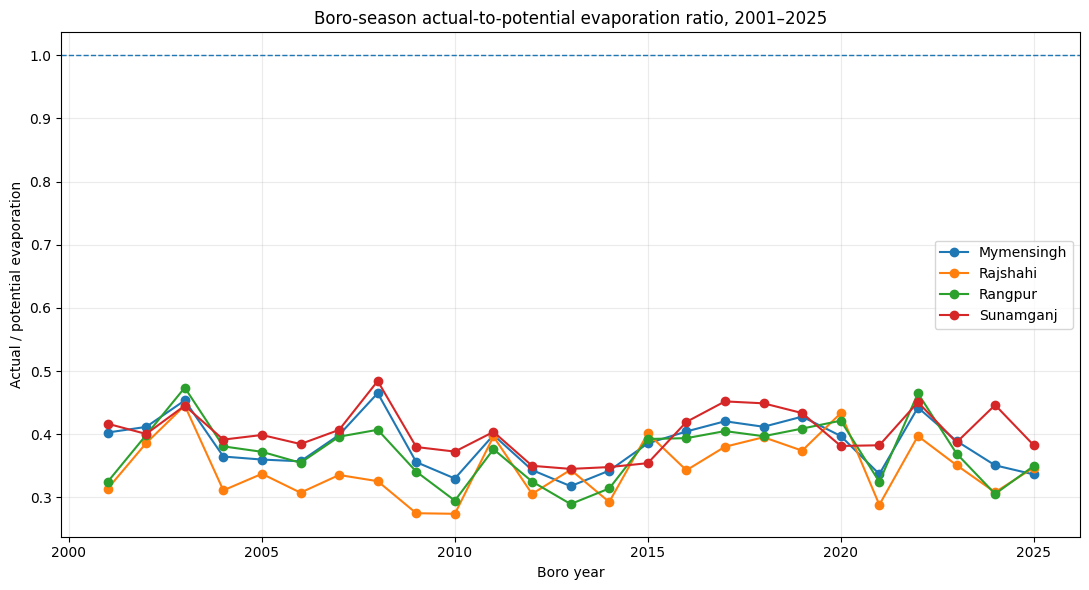

In [ ]:
# ============================================================
# FIGURE 4 — ET/PET
# ============================================================

plt.figure(figsize=(11, 6))

for district in districts:

    temp = panel[
        panel["District"] == district
    ].sort_values("BoroYear")

    plt.plot(
        temp["BoroYear"],
        temp["ET_PET_ratio"],
        marker="o",
        label=district
    )

plt.axhline(
    1,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Boro year")
plt.ylabel("Actual / potential evaporation")
plt.title(
    "Boro-season actual-to-potential evaporation ratio, 2001–2025"
)

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

plt.savefig(
    drive_path +
    "Figure4_ET_PET_Trajectory.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

Dataset shape: (4598, 13)

Columns:
['system:index', 'Baseline_ET_PET', 'Baseline_LST', 'Baseline_PET', 'Baseline_Productivity', 'Baseline_Rain', 'Delta_ET_PET', 'Delta_LST', 'Delta_PET', 'Delta_Rain', 'District', 'Trajectory_Class', '.geo']

Trajectory classes:
Trajectory_Class
1    1500
2    1000
3     598
4    1500
Name: count, dtype: int64

Districts:
District
Mymensingh    1598
Rajshahi      1000
Rangpur       1000
Sunamganj     1000
Name: count, dtype: int64

Clean ML dataset: (4598, 11)

Districts used for validation:
['Mymensingh', 'Rajshahi', 'Rangpur', 'Sunamganj']
RF | Held-out district: Mymensingh | Accuracy: 0.591
RF | Held-out district: Rajshahi | Accuracy: 0.438
RF | Held-out district: Rangpur | Accuracy: 0.443
RF | Held-out district: Sunamganj | Accuracy: 0.494

RANDOM FOREST
Accuracy: 0.5046
Balanced accuracy: 0.4902
Macro F1: 0.4762

Classification report:
              precision    recall  f1-score   support

           1      0.425     0.368     0.394      1500
    

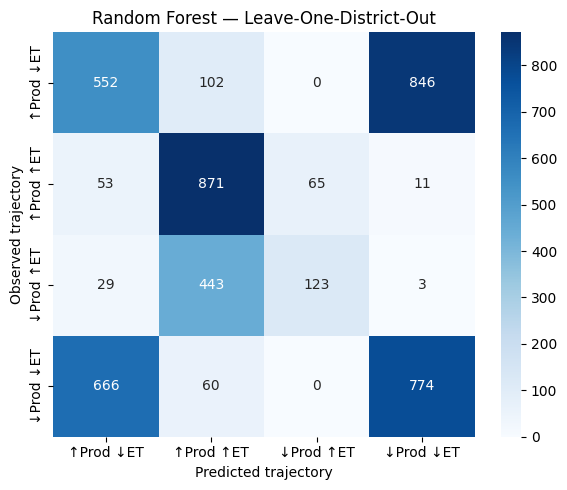


Random Forest feature importance:
                 Feature  Importance
3          Baseline_Rain    0.217166
7        Baseline_ET_PET    0.185877
5           Baseline_PET    0.121542
0  Baseline_Productivity    0.099792
4             Delta_Rain    0.096647
1           Baseline_LST    0.094338
8           Delta_ET_PET    0.063410
2              Delta_LST    0.061763
6              Delta_PET    0.059466


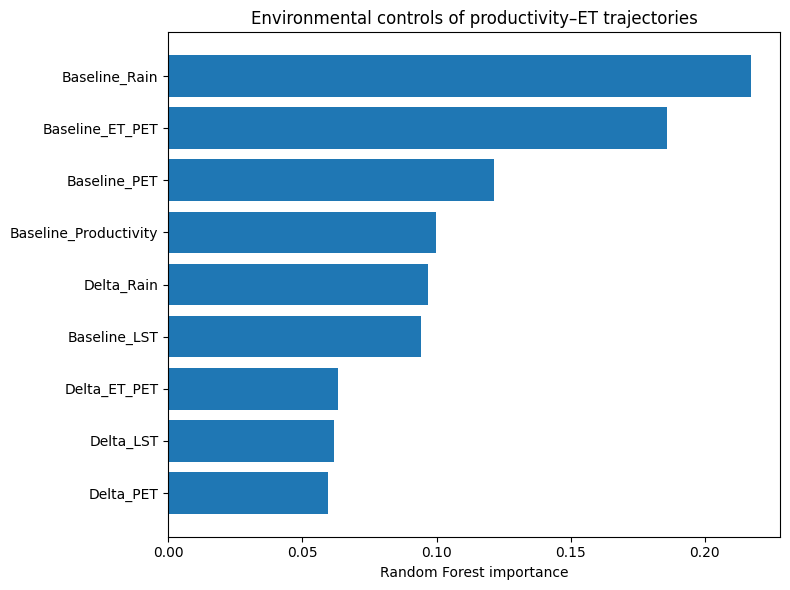

XGB | Held-out district: Mymensingh | Accuracy: 0.330
XGB | Held-out district: Rajshahi | Accuracy: 0.465
XGB | Held-out district: Rangpur | Accuracy: 0.471
XGB | Held-out district: Sunamganj | Accuracy: 0.439

XGBOOST
Accuracy: 0.4139
Balanced accuracy: 0.3754
Macro F1: 0.3885

Classification report:
              precision    recall  f1-score   support

           1      0.445     0.373     0.406      1500
           2      0.487     0.310     0.379      1000
           3      0.586     0.216     0.315       598
           4      0.364     0.603     0.454      1500

    accuracy                          0.414      4598
   macro avg      0.471     0.375     0.389      4598
weighted avg      0.446     0.414     0.404      4598



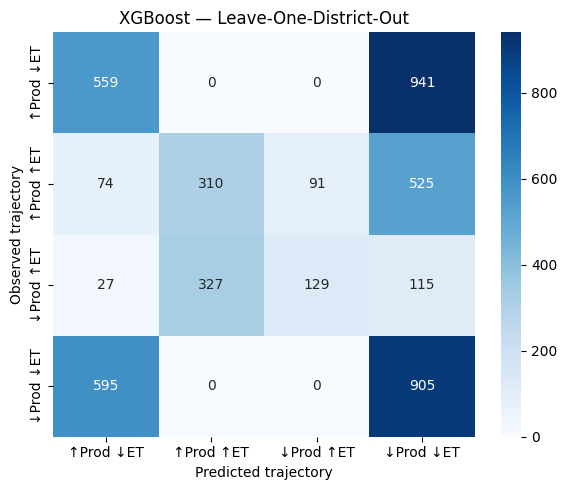


XGBoost feature importance:
                 Feature  Importance
3          Baseline_Rain    0.333748
7        Baseline_ET_PET    0.234472
5           Baseline_PET    0.107827
8           Delta_ET_PET    0.078095
6              Delta_PET    0.069422
4             Delta_Rain    0.052425
0  Baseline_Productivity    0.047309
1           Baseline_LST    0.042517
2              Delta_LST    0.034183


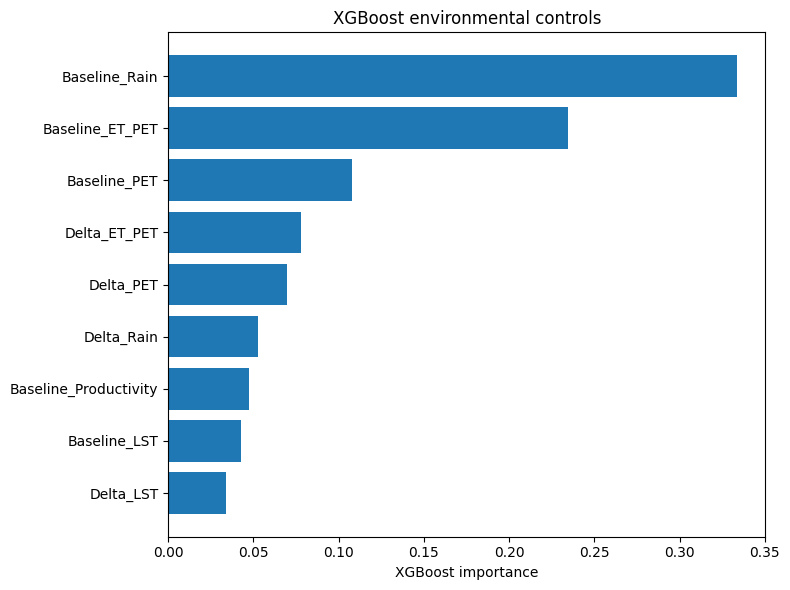


Running SHAP analysis...


<Figure size 640x480 with 0 Axes>

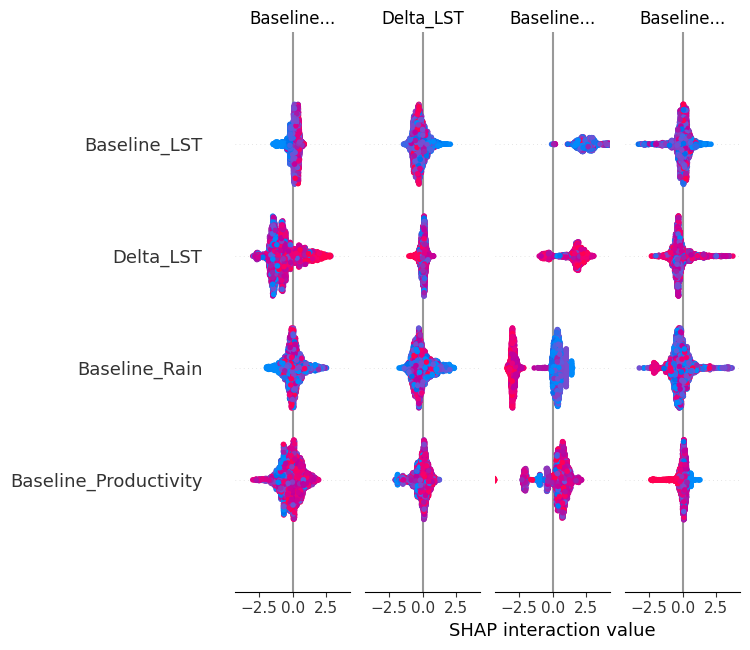


SHAP importance:
                 Feature  Mean_abs_SHAP
3          Baseline_Rain       1.986630
7        Baseline_ET_PET       0.597223
4             Delta_Rain       0.472846
1           Baseline_LST       0.335713
5           Baseline_PET       0.251772
0  Baseline_Productivity       0.228346
2              Delta_LST       0.203325
8           Delta_ET_PET       0.166723
6              Delta_PET       0.110923


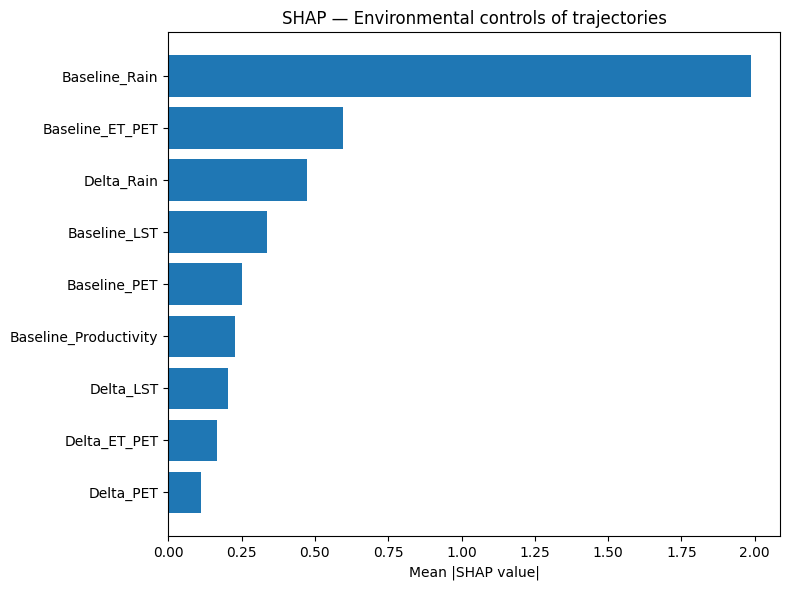


MODEL COMPARISON
           Model  Accuracy  Balanced_Accuracy  Macro_F1
0  Random Forest  0.504567           0.490171  0.476189
1        XGBoost  0.413876           0.375430  0.388510

All ML results saved to:
/content/drive/MyDrive/Nature_sustain_boro/


In [ ]:
# ============================================================
# STEP 20 — MACHINE LEARNING:
# RANDOM FOREST + XGBOOST + SHAP
# District-based validation
# ============================================================

# -----------------------------
# 20.1 Install packages
# -----------------------------
!pip -q install xgboost shap


# -----------------------------
# 20.2 Imports
# -----------------------------
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier
import shap


# -----------------------------
# 20.3 Paths
# -----------------------------
drive_path = '/content/drive/MyDrive/Nature_sustain_boro/'

file_path = os.path.join(
    drive_path,
    'Boro_Productivity_ET_ML_Sample_2001_2025_update.csv'
)

df = pd.read_csv(file_path)

print('Dataset shape:', df.shape)
print('\nColumns:')
print(df.columns.tolist())

print('\nTrajectory classes:')
print(df['Trajectory_Class'].value_counts().sort_index())

print('\nDistricts:')
print(df['District'].value_counts())


# ============================================================
# 20.4 ML VARIABLES
# ============================================================

features = [
    'Baseline_Productivity',
    'Baseline_LST',
    'Delta_LST',
    'Baseline_Rain',
    'Delta_Rain',
    'Baseline_PET',
    'Delta_PET',
    'Baseline_ET_PET',
    'Delta_ET_PET'
]

target = 'Trajectory_Class'
group = 'District'


# -----------------------------
# Check variables
# -----------------------------
required = features + [target, group]

missing = [c for c in required if c not in df.columns]

if missing:
    raise ValueError(
        'Missing columns: ' + str(missing)
    )


# -----------------------------
# Clean data
# -----------------------------
ml = df[required].copy()

ml = ml.replace([np.inf, -np.inf], np.nan)
ml = ml.dropna().reset_index(drop=True)

print('\nClean ML dataset:', ml.shape)


X = ml[features]
y = ml[target].astype(int)
groups = ml[group]


# ============================================================
# 20.5 LEAVE-ONE-DISTRICT-OUT VALIDATION
# ============================================================

districts = sorted(groups.unique())

print('\nDistricts used for validation:')
print(districts)


# ============================================================
# 20.6 RANDOM FOREST
# ============================================================

rf_predictions = []
rf_actual = []
rf_district = []

rf_models = {}


for test_district in districts:

    train_mask = groups != test_district
    test_mask = groups == test_district

    X_train = X.loc[train_mask]
    X_test = X.loc[test_mask]

    y_train = y.loc[train_mask]
    y_test = y.loc[test_mask]

    rf = RandomForestClassifier(
        n_estimators=500,
        max_features='sqrt',
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    pred = rf.predict(X_test)

    rf_predictions.extend(pred)
    rf_actual.extend(y_test)
    rf_district.extend([test_district] * len(y_test))

    rf_models[test_district] = rf

    print(
        f'RF | Held-out district: {test_district} | '
        f'Accuracy: {accuracy_score(y_test, pred):.3f}'
    )


rf_predictions = np.array(rf_predictions)
rf_actual = np.array(rf_actual)


# ============================================================
# 20.7 RANDOM FOREST PERFORMANCE
# ============================================================

rf_accuracy = accuracy_score(
    rf_actual,
    rf_predictions
)

rf_balanced_accuracy = balanced_accuracy_score(
    rf_actual,
    rf_predictions
)

rf_f1 = f1_score(
    rf_actual,
    rf_predictions,
    average='macro'
)

print('\n======================================')
print('RANDOM FOREST')
print('======================================')

print('Accuracy:', round(rf_accuracy, 4))
print('Balanced accuracy:', round(rf_balanced_accuracy, 4))
print('Macro F1:', round(rf_f1, 4))

print('\nClassification report:')
print(
    classification_report(
        rf_actual,
        rf_predictions,
        digits=3
    )
)


# ============================================================
# 20.8 RANDOM FOREST CONFUSION MATRIX
# ============================================================

cm_rf = confusion_matrix(
    rf_actual,
    rf_predictions,
    labels=[1, 2, 3, 4]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[
        '↑Prod ↓ET',
        '↑Prod ↑ET',
        '↓Prod ↑ET',
        '↓Prod ↓ET'
    ],
    yticklabels=[
        '↑Prod ↓ET',
        '↑Prod ↑ET',
        '↓Prod ↑ET',
        '↓Prod ↓ET'
    ]
)

plt.xlabel('Predicted trajectory')
plt.ylabel('Observed trajectory')
plt.title('Random Forest — Leave-One-District-Out')
plt.tight_layout()
plt.show()


# ============================================================
# 20.9 RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

# Fit final RF using all observations
rf_final = RandomForestClassifier(
    n_estimators=500,
    max_features='sqrt',
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X, y)

rf_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_final.feature_importances_
}).sort_values(
    'Importance',
    ascending=False
)

print('\nRandom Forest feature importance:')
print(rf_importance)


plt.figure(figsize=(8, 6))

plt.barh(
    rf_importance['Feature'],
    rf_importance['Importance']
)

plt.gca().invert_yaxis()

plt.xlabel('Random Forest importance')
plt.ylabel('')
plt.title('Environmental controls of productivity–ET trajectories')
plt.tight_layout()
plt.show()


# ============================================================
# 20.10 XGBOOST
# ============================================================

xgb_predictions = []
xgb_actual = []
xgb_district = []

xgb_models = {}


for test_district in districts:

    train_mask = groups != test_district
    test_mask = groups == test_district

    X_train = X.loc[train_mask]
    X_test = X.loc[test_mask]

    y_train = y.loc[train_mask] - 1
    y_test_original = y.loc[test_mask]

    xgb = XGBClassifier(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='multi:softprob',
        num_class=4,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    )

    xgb.fit(
        X_train,
        y_train
    )

    pred = xgb.predict(X_test) + 1

    xgb_predictions.extend(pred)
    xgb_actual.extend(y_test_original)
    xgb_district.extend(
        [test_district] * len(y_test_original)
    )

    xgb_models[test_district] = xgb

    print(
        f'XGB | Held-out district: {test_district} | '
        f'Accuracy: '
        f'{accuracy_score(y_test_original, pred):.3f}'
    )


xgb_predictions = np.array(xgb_predictions)
xgb_actual = np.array(xgb_actual)


# ============================================================
# 20.11 XGBOOST PERFORMANCE
# ============================================================

xgb_accuracy = accuracy_score(
    xgb_actual,
    xgb_predictions
)

xgb_balanced_accuracy = balanced_accuracy_score(
    xgb_actual,
    xgb_predictions
)

xgb_f1 = f1_score(
    xgb_actual,
    xgb_predictions,
    average='macro'
)

print('\n======================================')
print('XGBOOST')
print('======================================')

print('Accuracy:', round(xgb_accuracy, 4))
print('Balanced accuracy:', round(xgb_balanced_accuracy, 4))
print('Macro F1:', round(xgb_f1, 4))

print('\nClassification report:')
print(
    classification_report(
        xgb_actual,
        xgb_predictions,
        digits=3
    )
)


# ============================================================
# 20.12 XGBOOST CONFUSION MATRIX
# ============================================================

cm_xgb = confusion_matrix(
    xgb_actual,
    xgb_predictions,
    labels=[1, 2, 3, 4]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[
        '↑Prod ↓ET',
        '↑Prod ↑ET',
        '↓Prod ↑ET',
        '↓Prod ↓ET'
    ],
    yticklabels=[
        '↑Prod ↓ET',
        '↑Prod ↑ET',
        '↓Prod ↑ET',
        '↓Prod ↓ET'
    ]
)

plt.xlabel('Predicted trajectory')
plt.ylabel('Observed trajectory')
plt.title('XGBoost — Leave-One-District-Out')
plt.tight_layout()
plt.show()


# ============================================================
# 20.13 FINAL XGBOOST MODEL
# ============================================================

xgb_final = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=4,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

xgb_final.fit(
    X,
    y - 1
)


# ============================================================
# 20.14 XGBOOST FEATURE IMPORTANCE
# ============================================================

xgb_importance = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_final.feature_importances_
}).sort_values(
    'Importance',
    ascending=False
)

print('\nXGBoost feature importance:')
print(xgb_importance)


plt.figure(figsize=(8, 6))

plt.barh(
    xgb_importance['Feature'],
    xgb_importance['Importance']
)

plt.gca().invert_yaxis()

plt.xlabel('XGBoost importance')
plt.ylabel('')
plt.title('XGBoost environmental controls')
plt.tight_layout()
plt.show()


# ============================================================
# 20.15 SHAP ANALYSIS
# ============================================================

print('\nRunning SHAP analysis...')

explainer = shap.TreeExplainer(xgb_final)

shap_values = explainer.shap_values(X)


# ============================================================
# 20.16 SHAP SUMMARY
# ============================================================

plt.figure()

shap.summary_plot(
    shap_values,
    X,
    feature_names=features,
    show=False
)

plt.tight_layout()
plt.show()


# ============================================================
# 20.17 SHAP FEATURE IMPORTANCE
# ============================================================

# Handle SHAP versions returning either:
#   list of arrays
# or
#   3-D numpy array

if isinstance(shap_values, list):

    mean_abs_shap = np.mean(
        [
            np.abs(v).mean(axis=0)
            for v in shap_values
        ],
        axis=0
    )

else:

    if shap_values.ndim == 3:

        mean_abs_shap = np.abs(
            shap_values
        ).mean(axis=(0, 2))

    else:

        mean_abs_shap = np.abs(
            shap_values
        ).mean(axis=0)


shap_importance = pd.DataFrame({
    'Feature': features,
    'Mean_abs_SHAP': mean_abs_shap
}).sort_values(
    'Mean_abs_SHAP',
    ascending=False
)

print('\nSHAP importance:')
print(shap_importance)


plt.figure(figsize=(8, 6))

plt.barh(
    shap_importance['Feature'],
    shap_importance['Mean_abs_SHAP']
)

plt.gca().invert_yaxis()

plt.xlabel('Mean |SHAP value|')
plt.ylabel('')
plt.title('SHAP — Environmental controls of trajectories')
plt.tight_layout()
plt.show()


# ============================================================
# 20.18 SAVE RESULTS
# ============================================================

results = pd.DataFrame({
    'Model': [
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy': [
        rf_accuracy,
        xgb_accuracy
    ],
    'Balanced_Accuracy': [
        rf_balanced_accuracy,
        xgb_balanced_accuracy
    ],
    'Macro_F1': [
        rf_f1,
        xgb_f1
    ]
})

print('\nMODEL COMPARISON')
print(results)


results.to_csv(
    os.path.join(
        drive_path,
        'Boro_ML_Model_Performance_2001_2025.csv'
    ),
    index=False
)

rf_importance.to_csv(
    os.path.join(
        drive_path,
        'Boro_RF_Feature_Importance_2001_2025.csv'
    ),
    index=False
)

xgb_importance.to_csv(
    os.path.join(
        drive_path,
        'Boro_XGB_Feature_Importance_2001_2025.csv'
    ),
    index=False
)

shap_importance.to_csv(
    os.path.join(
        drive_path,
        'Boro_SHAP_Feature_Importance_2001_2025.csv'
    ),
    index=False
)

print('\nAll ML results saved to:')
print(drive_path)

In [ ]:
print(ml['Trajectory_Class'].value_counts().sort_index())
print(
    ml['Trajectory_Class'].value_counts(normalize=True).sort_index()
)

Trajectory_Class
1    1500
2    1000
3     598
4    1500
Name: count, dtype: int64
Trajectory_Class
1    0.326229
2    0.217486
3    0.130057
4    0.326229
Name: proportion, dtype: float64


Dataset shape: (4598, 13)

Clean ML dataset: (4598, 9)

Trajectory class distribution:
                  Count  Proportion
Trajectory_Class                   
1                  1500    0.326229
2                  1000    0.217486
3                   598    0.130057
4                  1500    0.326229

Majority-class baseline: 0.3262

Final predictors:
['Baseline_Productivity', 'Baseline_LST', 'Delta_LST', 'Baseline_Rain', 'Delta_Rain', 'Baseline_PET', 'Delta_PET', 'Rain_PET_balance', 'Delta_Rain_PET', 'Rain_PET_ratio', 'LST_Rain_interaction', 'LST_PET_interaction']

Districts:
['Mymensingh', 'Rajshahi', 'Rangpur', 'Sunamganj']

Number of districts: 4

LODO 1/4
Held-out district: Mymensingh
Train: 3000 | Test: 1598

Tuning Random Forest...
Best RF: {'n_estimators': 400, 'min_samples_leaf': 1, 'max_features': 0.8, 'max_depth': 30}

Tuning XGBoost...
Best XGB: {'subsample': 0.8, 'n_estimators': 700, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.03, 'colsample_bytree': 0.8}

R

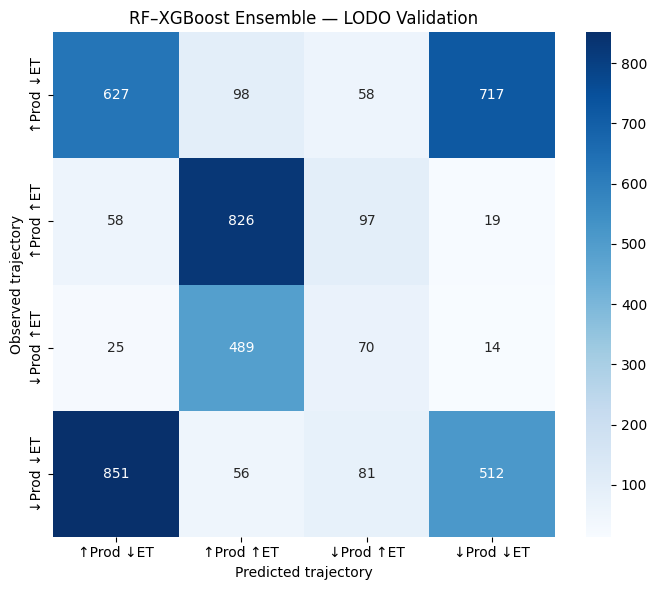

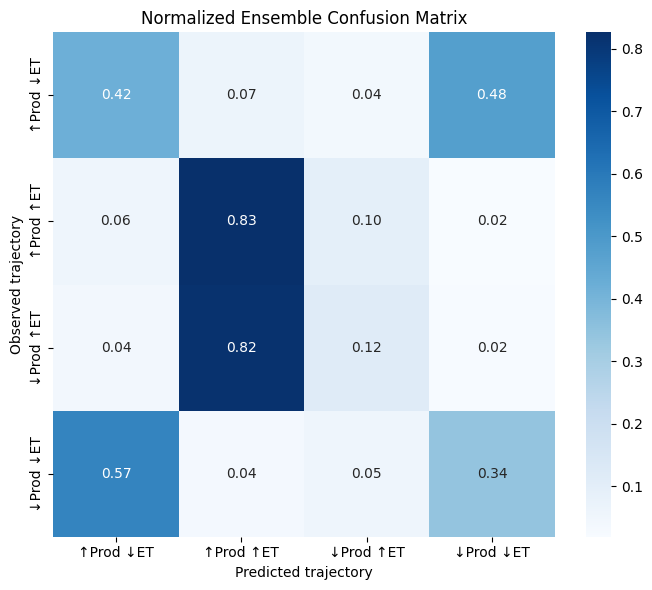


Prediction file saved:
/content/drive/MyDrive/Nature_sustain_boro/Boro_ML_LODO_Predictions_FAST_2001_2025.csv

District-level performance:
     District     N  RF_Accuracy  XGB_Accuracy  Ensemble_Accuracy
0  Mymensingh  1598       0.3817        0.3992              0.505
1    Rajshahi  1000       0.4470        0.3990              0.381
2     Rangpur  1000       0.4090        0.3850              0.406
3   Sunamganj  1000       0.4680        0.4140              0.441

Training final RF...

RF feature importance:
                  Feature  Importance
3           Baseline_Rain    0.147311
9          Rain_PET_ratio    0.130502
7        Rain_PET_balance    0.111395
5            Baseline_PET    0.109876
1            Baseline_LST    0.092796
0   Baseline_Productivity    0.091397
4              Delta_Rain    0.060053
6               Delta_PET    0.059081
8          Delta_Rain_PET    0.058229
10   LST_Rain_interaction    0.048007
2               Delta_LST    0.047017
11    LST_PET_interaction   

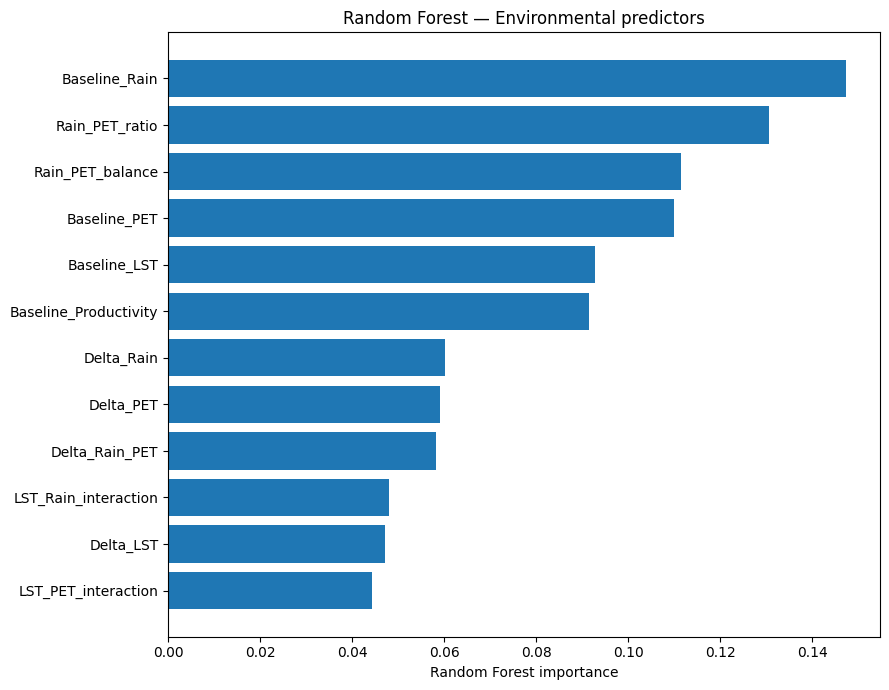


Training final XGBoost...

XGBoost feature importance:
                  Feature  Importance
3           Baseline_Rain    0.308648
9          Rain_PET_ratio    0.221291
7        Rain_PET_balance    0.095095
5            Baseline_PET    0.094888
6               Delta_PET    0.071385
0   Baseline_Productivity    0.039575
1            Baseline_LST    0.034251
8          Delta_Rain_PET    0.031988
4              Delta_Rain    0.031159
2               Delta_LST    0.028901
10   LST_Rain_interaction    0.021525
11    LST_PET_interaction    0.021293


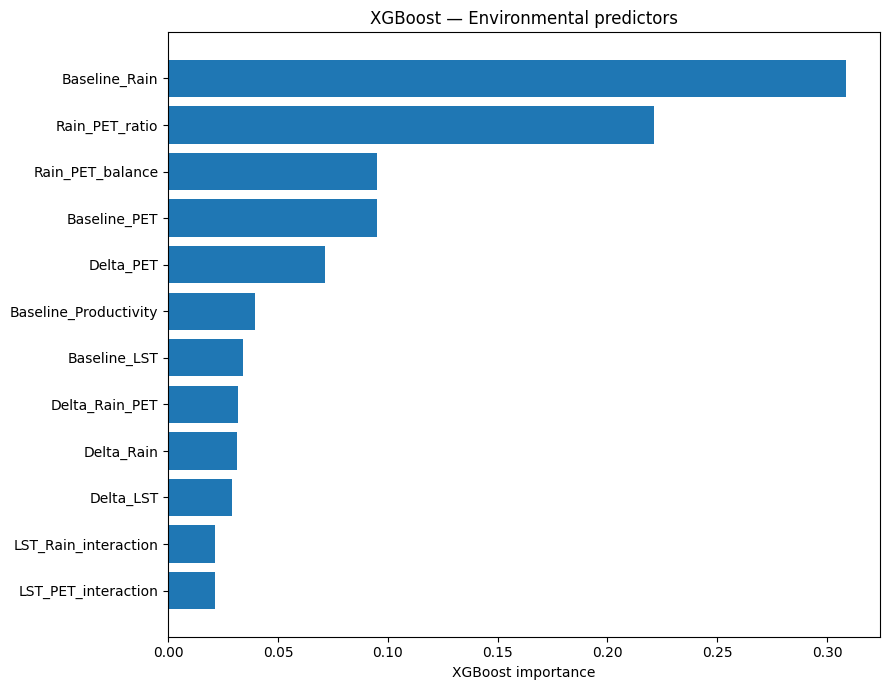


Running SHAP...


<Figure size 1000x700 with 0 Axes>

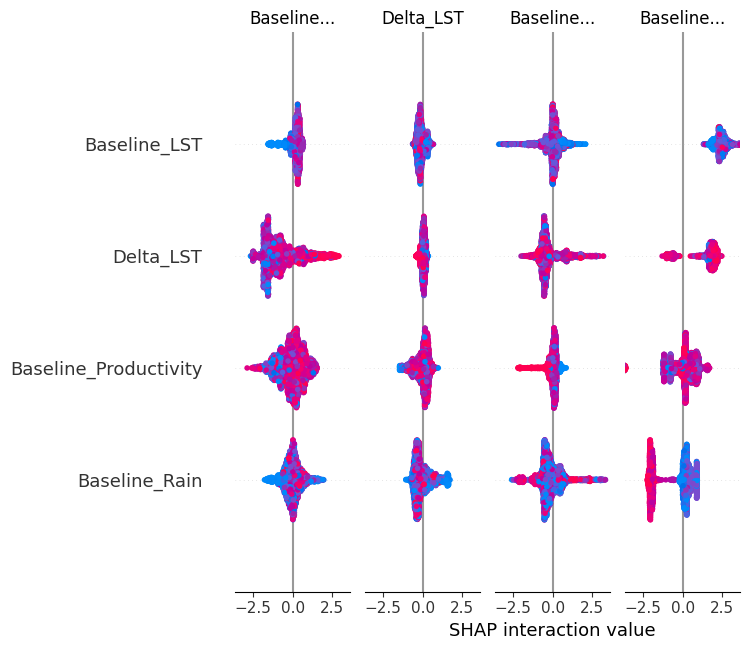


SHAP importance:
                  Feature  Mean_abs_SHAP
3           Baseline_Rain       1.691980
9          Rain_PET_ratio       0.624314
5            Baseline_PET       0.359772
1            Baseline_LST       0.347351
8          Delta_Rain_PET       0.320893
0   Baseline_Productivity       0.243198
7        Rain_PET_balance       0.221776
4              Delta_Rain       0.220292
6               Delta_PET       0.178170
2               Delta_LST       0.143835
10   LST_Rain_interaction       0.085286
11    LST_PET_interaction       0.078259


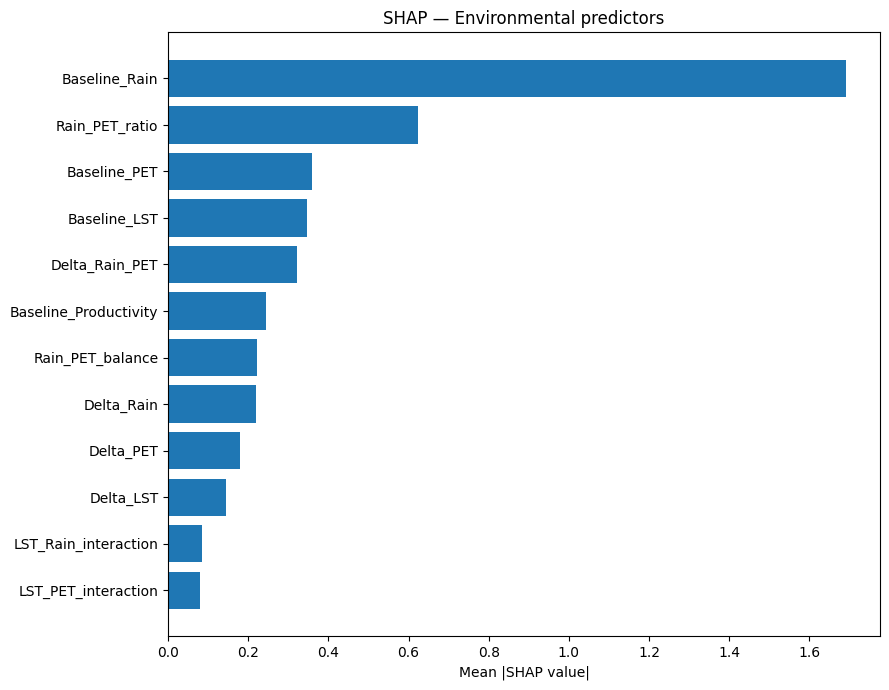


Generating class-specific SHAP plots...


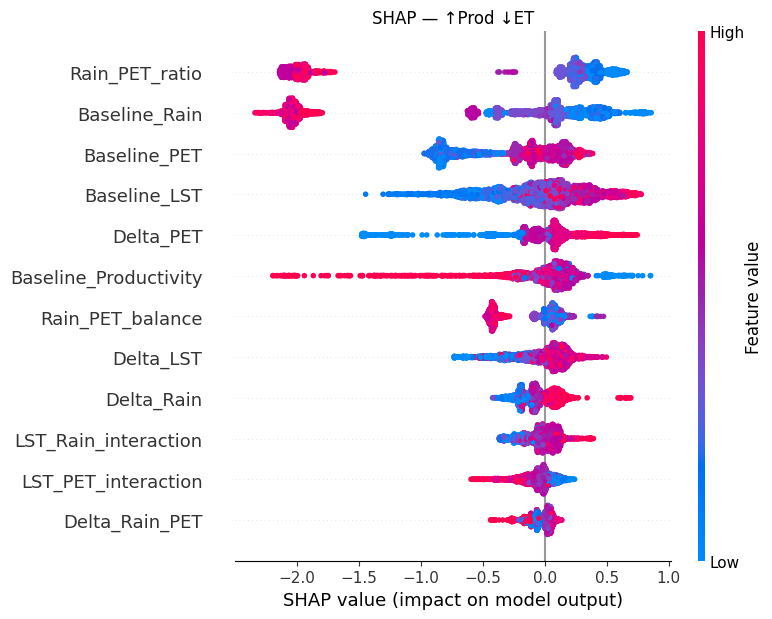

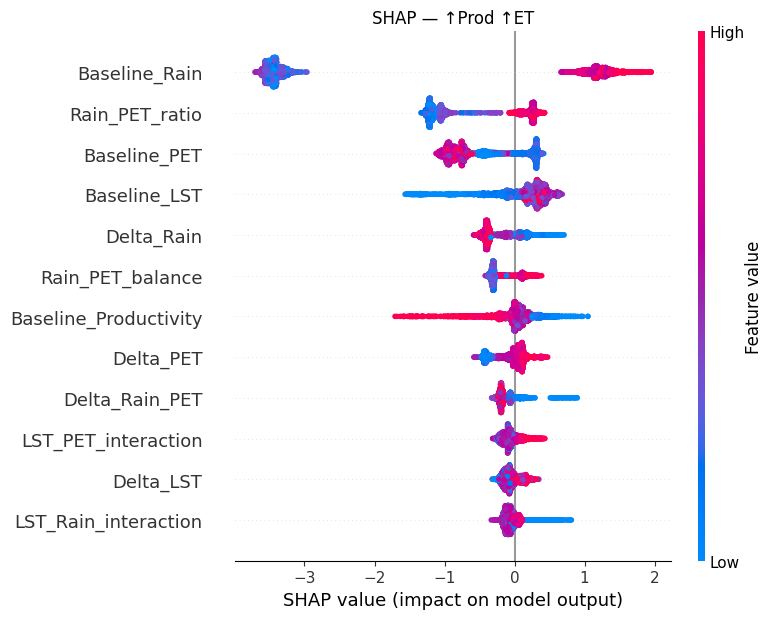

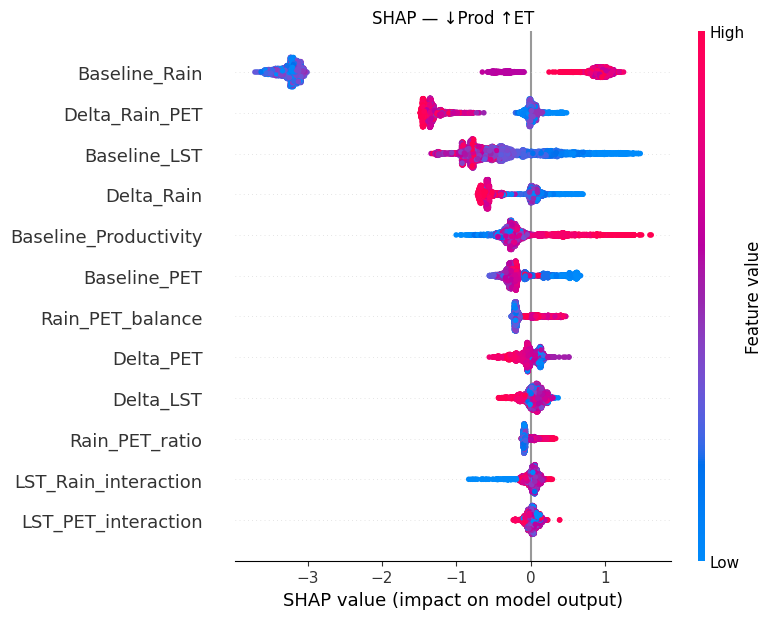

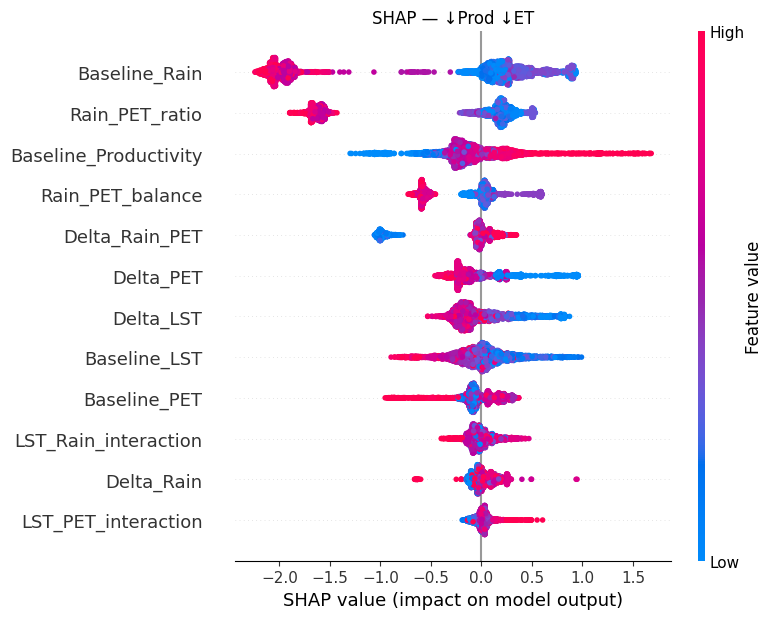


STEP 20 COMPLETED

Model performance:
                   Model  Accuracy  Balanced_Accuracy  Macro_F1
0          Random Forest    0.4206             0.4067    0.3795
1                XGBoost    0.3993             0.3723    0.3766
2  RF + XGBoost Ensemble    0.4426             0.4256    0.4011

Files saved to:
/content/drive/MyDrive/Nature_sustain_boro/


In [ ]:
# ============================================================
# STEP 20 — FAST OPTIMIZED MACHINE LEARNING
# RF + XGBOOST + ENSEMBLE + SHAP
# LEAVE-ONE-DISTRICT-OUT VALIDATION
# ============================================================

# ============================================================
# 20.1 INSTALL PACKAGES
# ============================================================

!pip -q install xgboost shap


# ============================================================
# 20.2 IMPORTS
# ============================================================

import os
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier
import shap


# ============================================================
# 20.3 PATHS
# ============================================================

drive_path = '/content/drive/MyDrive/Nature_sustain_boro/'

file_path = os.path.join(
    drive_path,
    'Boro_Productivity_ET_ML_Sample_2001_2025_update.csv'
)

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)


# ============================================================
# 20.4 VARIABLES
# ============================================================

# IMPORTANT:
# Delta_ET_PET is excluded because ET change may have been used
# to construct Trajectory_Class.
#
# This avoids target leakage.

features = [
    'Baseline_Productivity',
    'Baseline_LST',
    'Delta_LST',
    'Baseline_Rain',
    'Delta_Rain',
    'Baseline_PET',
    'Delta_PET'
]

target = 'Trajectory_Class'

group = 'District'


# ============================================================
# 20.5 CHECK VARIABLES
# ============================================================

required = features + [target, group]

missing = [
    c for c in required
    if c not in df.columns
]

if missing:

    raise ValueError(
        "Missing columns: " + str(missing)
    )


# ============================================================
# 20.6 CLEAN DATA
# ============================================================

ml = df[
    required
].copy()

ml = ml.replace(
    [np.inf, -np.inf],
    np.nan
)

ml = ml.dropna().reset_index(
    drop=True
)


print(
    "\nClean ML dataset:",
    ml.shape
)


# ============================================================
# 20.7 X, Y, GROUP
# ============================================================

X = ml[
    features
].copy()

y = ml[
    target
].astype(int)

groups = ml[
    group
].copy()


# ============================================================
# 20.8 CLASS DISTRIBUTION
# ============================================================

class_distribution = pd.DataFrame({

    'Count':
        y.value_counts().sort_index(),

    'Proportion':
        y.value_counts(
            normalize=True
        ).sort_index()

})

print(
    "\nTrajectory class distribution:"
)

print(
    class_distribution
)


majority_baseline = (
    y.value_counts(
        normalize=True
    ).max()
)

print(
    "\nMajority-class baseline:",
    round(
        majority_baseline,
        4
    )
)


# ============================================================
# 20.9 OPTIONAL FEATURE ENGINEERING
# ============================================================

# These variables are constructed only from predictor variables.
# They are not based on Trajectory_Class.

X['Rain_PET_balance'] = (
    X['Baseline_Rain']
    -
    X['Baseline_PET']
)

X['Delta_Rain_PET'] = (
    X['Delta_Rain']
    -
    X['Delta_PET']
)

X['Rain_PET_ratio'] = (
    X['Baseline_Rain']
    /
    (
        X['Baseline_PET'].abs()
        + 1e-6
    )
)

X['LST_Rain_interaction'] = (
    X['Delta_LST']
    *
    X['Delta_Rain']
)

X['LST_PET_interaction'] = (
    X['Delta_LST']
    *
    X['Delta_PET']
)


features_final = X.columns.tolist()


print(
    "\nFinal predictors:"
)

print(
    features_final
)


# ============================================================
# 20.10 DISTRICTS
# ============================================================

districts = sorted(
    groups.unique()
)

print(
    "\nDistricts:"
)

print(
    districts
)

print(
    "\nNumber of districts:",
    len(districts)
)


# ============================================================
# 20.11 FAST HYPERPARAMETER GRIDS
# ============================================================

# ------------------------------------------------------------
# Random Forest
# ------------------------------------------------------------

rf_param_grid = {

    'n_estimators': [
        400,
        700
    ],

    'max_depth': [
        None,
        20,
        30
    ],

    'min_samples_leaf': [
        1,
        2,
        4
    ],

    'max_features': [
        'sqrt',
        0.8
    ]
}


# ------------------------------------------------------------
# XGBoost
# ------------------------------------------------------------

xgb_param_grid = {

    'n_estimators': [
        300,
        500,
        700
    ],

    'max_depth': [
        2,
        3,
        4
    ],

    'learning_rate': [
        0.03,
        0.05,
        0.10
    ],

    'min_child_weight': [
        1,
        3
    ],

    'subsample': [
        0.8
    ],

    'colsample_bytree': [
        0.8
    ]
}


# ============================================================
# 20.12 STORAGE
# ============================================================

rf_predictions = []
xgb_predictions = []
ensemble_predictions = []

actual_values = []

prediction_districts = []

rf_probabilities = []
xgb_probabilities = []
ensemble_probabilities = []


# Store best parameters

rf_best_parameters = {}

xgb_best_parameters = {}


# ============================================================
# 20.13 FAST LODO LOOP
# ============================================================

for i, test_district in enumerate(
    districts,
    start=1
):

    print(
        "\n"
        + "=" * 65
    )

    print(
        f"LODO {i}/{len(districts)}"
    )

    print(
        "Held-out district:",
        test_district
    )

    print(
        "=" * 65
    )


    # --------------------------------------------------------
    # TRAIN / TEST
    # --------------------------------------------------------

    train_mask = (
        groups != test_district
    )

    test_mask = (
        groups == test_district
    )


    X_train = X.loc[
        train_mask
    ]

    X_test = X.loc[
        test_mask
    ]

    y_train = y.loc[
        train_mask
    ]

    y_test = y.loc[
        test_mask
    ]


    print(
        "Train:",
        len(X_train),
        "| Test:",
        len(X_test)
    )


    # ========================================================
    # 20.13.1 FAST RANDOM FOREST TUNING
    # ========================================================

    print(
        "\nTuning Random Forest..."
    )


    rf_base = RandomForestClassifier(

        class_weight='balanced',

        random_state=42,

        n_jobs=-1
    )


    inner_cv = StratifiedKFold(

        n_splits=3,

        shuffle=True,

        random_state=42
    )


    rf_search = RandomizedSearchCV(

        estimator=rf_base,

        param_distributions=rf_param_grid,

        n_iter=8,

        scoring='accuracy',

        cv=inner_cv,

        random_state=42,

        n_jobs=-1,

        refit=True
    )


    rf_search.fit(
        X_train,
        y_train
    )


    rf_model = (
        rf_search.best_estimator_
    )


    rf_best_parameters[
        test_district
    ] = rf_search.best_params_


    print(
        "Best RF:",
        rf_search.best_params_
    )


    # --------------------------------------------------------
    # RF PREDICTION
    # --------------------------------------------------------

    rf_pred = rf_model.predict(
        X_test
    )

    rf_prob = rf_model.predict_proba(
        X_test
    )


    # ========================================================
    # 20.13.2 FAST XGBOOST TUNING
    # ========================================================

    print(
        "\nTuning XGBoost..."
    )


    xgb_base = XGBClassifier(

        objective='multi:softprob',

        num_class=4,

        eval_metric='mlogloss',

        random_state=42,

        n_jobs=-1,

        tree_method='hist'
    )


    xgb_search = RandomizedSearchCV(

        estimator=xgb_base,

        param_distributions=xgb_param_grid,

        n_iter=8,

        scoring='accuracy',

        cv=inner_cv,

        random_state=42,

        n_jobs=-1,

        refit=True
    )


    # XGBoost requires classes 0–3

    y_train_xgb = (
        y_train - 1
    )


    xgb_search.fit(

        X_train,

        y_train_xgb
    )


    xgb_model = (
        xgb_search.best_estimator_
    )


    xgb_best_parameters[
        test_district
    ] = xgb_search.best_params_


    print(
        "Best XGB:",
        xgb_search.best_params_
    )


    # --------------------------------------------------------
    # XGB PREDICTION
    # --------------------------------------------------------

    xgb_pred = (
        xgb_model.predict(
            X_test
        )
        + 1
    )


    xgb_prob = (
        xgb_model.predict_proba(
            X_test
        )
    )


    # ========================================================
    # 20.13.3 ENSEMBLE
    # ========================================================

    # Weighted probability ensemble

    ensemble_prob = (

        0.60 * rf_prob

        +

        0.40 * xgb_prob

    )


    ensemble_pred = (

        np.argmax(
            ensemble_prob,
            axis=1
        )

        + 1

    )


    # ========================================================
    # 20.13.4 STORE RESULTS
    # ========================================================

    rf_predictions.extend(
        rf_pred
    )

    xgb_predictions.extend(
        xgb_pred
    )

    ensemble_predictions.extend(
        ensemble_pred
    )

    actual_values.extend(
        y_test
    )

    prediction_districts.extend(
        [test_district] *
        len(y_test)
    )


    rf_probabilities.extend(
        rf_prob
    )

    xgb_probabilities.extend(
        xgb_prob
    )

    ensemble_probabilities.extend(
        ensemble_prob
    )


    # ========================================================
    # 20.13.5 DISTRICT PERFORMANCE
    # ========================================================

    print(
        "\nRF accuracy:",
        round(
            accuracy_score(
                y_test,
                rf_pred
            ),
            3
        )
    )

    print(
        "XGB accuracy:",
        round(
            accuracy_score(
                y_test,
                xgb_pred
            ),
            3
        )
    )

    print(
        "Ensemble accuracy:",
        round(
            accuracy_score(
                y_test,
                ensemble_pred
            ),
            3
        )
    )


# ============================================================
# 20.14 CONVERT TO ARRAYS
# ============================================================

rf_predictions = np.array(
    rf_predictions
)

xgb_predictions = np.array(
    xgb_predictions
)

ensemble_predictions = np.array(
    ensemble_predictions
)

actual_values = np.array(
    actual_values
)

rf_probabilities = np.array(
    rf_probabilities
)

xgb_probabilities = np.array(
    xgb_probabilities
)

ensemble_probabilities = np.array(
    ensemble_probabilities
)


# ============================================================
# 20.15 PERFORMANCE FUNCTION
# ============================================================

def model_metrics(
    actual,
    predicted
):

    return [

        accuracy_score(
            actual,
            predicted
        ),

        balanced_accuracy_score(
            actual,
            predicted
        ),

        f1_score(
            actual,
            predicted,
            average='macro'
        )

    ]


rf_metrics = model_metrics(
    actual_values,
    rf_predictions
)

xgb_metrics = model_metrics(
    actual_values,
    xgb_predictions
)

ensemble_metrics = model_metrics(
    actual_values,
    ensemble_predictions
)


# ============================================================
# 20.16 FINAL MODEL COMPARISON
# ============================================================

results = pd.DataFrame({

    'Model': [

        'Random Forest',

        'XGBoost',

        'RF + XGBoost Ensemble'

    ],

    'Accuracy': [

        rf_metrics[0],

        xgb_metrics[0],

        ensemble_metrics[0]

    ],

    'Balanced_Accuracy': [

        rf_metrics[1],

        xgb_metrics[1],

        ensemble_metrics[1]

    ],

    'Macro_F1': [

        rf_metrics[2],

        xgb_metrics[2],

        ensemble_metrics[2]

    ]

})


print(
    "\n"
    + "=" * 65
)

print(
    "FINAL MODEL COMPARISON"
)

print(
    "=" * 65
)

print(
    results.round(4)
)


# ============================================================
# 20.17 CLASS NAMES
# ============================================================

class_names = [

    '↑Prod ↓ET',

    '↑Prod ↑ET',

    '↓Prod ↑ET',

    '↓Prod ↓ET'

]


# ============================================================
# 20.18 RF CLASSIFICATION REPORT
# ============================================================

print(
    "\nRANDOM FOREST"
)

print(
    classification_report(

        actual_values,

        rf_predictions,

        labels=[
            1, 2, 3, 4
        ],

        target_names=
        class_names,

        digits=3
    )
)


# ============================================================
# 20.19 XGBOOST CLASSIFICATION REPORT
# ============================================================

print(
    "\nXGBOOST"
)

print(
    classification_report(

        actual_values,

        xgb_predictions,

        labels=[
            1, 2, 3, 4
        ],

        target_names=
        class_names,

        digits=3
    )
)


# ============================================================
# 20.20 ENSEMBLE CLASSIFICATION REPORT
# ============================================================

print(
    "\nENSEMBLE"
)

print(
    classification_report(

        actual_values,

        ensemble_predictions,

        labels=[
            1, 2, 3, 4
        ],

        target_names=
        class_names,

        digits=3
    )
)


# ============================================================
# 20.21 ENSEMBLE CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(

    actual_values,

    ensemble_predictions,

    labels=[
        1, 2, 3, 4
    ]

)


plt.figure(
    figsize=(7, 6)
)

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=
    class_names,

    yticklabels=
    class_names

)


plt.xlabel(
    'Predicted trajectory'
)

plt.ylabel(
    'Observed trajectory'
)

plt.title(
    'RF–XGBoost Ensemble — LODO Validation'
)

plt.tight_layout()

plt.show()


# ============================================================
# 20.22 NORMALIZED CONFUSION MATRIX
# ============================================================

cm_normalized = (

    cm /

    cm.sum(
        axis=1,
        keepdims=True
    )

)


plt.figure(
    figsize=(7, 6)
)

sns.heatmap(

    cm_normalized,

    annot=True,

    fmt='.2f',

    cmap='Blues',

    xticklabels=
    class_names,

    yticklabels=
    class_names

)


plt.xlabel(
    'Predicted trajectory'
)

plt.ylabel(
    'Observed trajectory'
)

plt.title(
    'Normalized Ensemble Confusion Matrix'
)

plt.tight_layout()

plt.show()


# ============================================================
# 20.23 SAVE LODO PREDICTIONS
# ============================================================

prediction_results = pd.DataFrame({

    'District':
        prediction_districts,

    'Observed_Trajectory':
        actual_values,

    'RF_Predicted':
        rf_predictions,

    'XGB_Predicted':
        xgb_predictions,

    'Ensemble_Predicted':
        ensemble_predictions,

    'RF_Confidence':
        np.max(
            rf_probabilities,
            axis=1
        ),

    'XGB_Confidence':
        np.max(
            xgb_probabilities,
            axis=1
        ),

    'Ensemble_Confidence':
        np.max(
            ensemble_probabilities,
            axis=1
        )

})


prediction_file = os.path.join(

    drive_path,

    'Boro_ML_LODO_Predictions_FAST_2001_2025.csv'

)


prediction_results.to_csv(

    prediction_file,

    index=False

)


print(
    "\nPrediction file saved:"
)

print(
    prediction_file
)


# ============================================================
# 20.24 DISTRICT-LEVEL PERFORMANCE
# ============================================================

district_performance = []


for district in districts:

    mask = (

        np.array(
            prediction_districts
        )
        ==
        district

    )


    district_performance.append({

        'District':
            district,

        'N':
            mask.sum(),

        'RF_Accuracy':
            accuracy_score(

                actual_values[mask],

                rf_predictions[mask]

            ),

        'XGB_Accuracy':
            accuracy_score(

                actual_values[mask],

                xgb_predictions[mask]

            ),

        'Ensemble_Accuracy':
            accuracy_score(

                actual_values[mask],

                ensemble_predictions[mask]

            )

    })


district_performance = pd.DataFrame(
    district_performance
)


print(
    "\nDistrict-level performance:"
)

print(
    district_performance.round(4)
)


district_performance.to_csv(

    os.path.join(

        drive_path,

        'Boro_ML_District_Performance_FAST.csv'

    ),

    index=False

)


# ============================================================
# 20.25 FINAL RF MODEL USING ALL OBSERVATIONS
# ============================================================

print(
    "\nTraining final RF..."
)


rf_final = RandomForestClassifier(

    n_estimators=700,

    max_depth=None,

    min_samples_split=2,

    min_samples_leaf=2,

    max_features='sqrt',

    class_weight='balanced',

    random_state=42,

    n_jobs=-1

)


rf_final.fit(

    X,

    y

)


# ============================================================
# 20.26 RF FEATURE IMPORTANCE
# ============================================================

rf_importance = pd.DataFrame({

    'Feature':
        features_final,

    'Importance':
        rf_final.feature_importances_

}).sort_values(

    'Importance',

    ascending=False

)


print(
    "\nRF feature importance:"
)

print(
    rf_importance
)


plt.figure(
    figsize=(9, 7)
)

plt.barh(

    rf_importance['Feature'],

    rf_importance['Importance']

)

plt.gca().invert_yaxis()

plt.xlabel(
    'Random Forest importance'
)

plt.title(
    'Random Forest — Environmental predictors'
)

plt.tight_layout()

plt.show()


# ============================================================
# 20.27 FINAL XGBOOST MODEL
# ============================================================

print(
    "\nTraining final XGBoost..."
)


xgb_final = XGBClassifier(

    n_estimators=500,

    max_depth=3,

    learning_rate=0.05,

    min_child_weight=1,

    subsample=0.8,

    colsample_bytree=0.8,

    objective='multi:softprob',

    num_class=4,

    eval_metric='mlogloss',

    random_state=42,

    n_jobs=-1,

    tree_method='hist'

)


xgb_final.fit(

    X,

    y - 1

)


# ============================================================
# 20.28 XGBOOST FEATURE IMPORTANCE
# ============================================================

xgb_importance = pd.DataFrame({

    'Feature':
        features_final,

    'Importance':
        xgb_final.feature_importances_

}).sort_values(

    'Importance',

    ascending=False

)


print(
    "\nXGBoost feature importance:"
)

print(
    xgb_importance
)


plt.figure(
    figsize=(9, 7)
)

plt.barh(

    xgb_importance['Feature'],

    xgb_importance['Importance']

)

plt.gca().invert_yaxis()

plt.xlabel(
    'XGBoost importance'
)

plt.title(
    'XGBoost — Environmental predictors'
)

plt.tight_layout()

plt.show()


# ============================================================
# 20.29 SHAP ANALYSIS
# ============================================================

print(
    "\nRunning SHAP..."
)


explainer = shap.TreeExplainer(
    xgb_final
)


shap_values = explainer.shap_values(
    X
)


# ============================================================
# 20.30 SHAP SUMMARY
# ============================================================

plt.figure(
    figsize=(10, 7)
)

shap.summary_plot(

    shap_values,

    X,

    feature_names=
    features_final,

    show=False

)

plt.tight_layout()

plt.show()


# ============================================================
# 20.31 SHAP GLOBAL IMPORTANCE
# ============================================================

if isinstance(
    shap_values,
    list
):

    mean_abs_shap = np.mean(

        [

            np.abs(
                v
            ).mean(
                axis=0
            )

            for v in shap_values

        ],

        axis=0

    )

else:

    if shap_values.ndim == 3:

        mean_abs_shap = np.abs(
            shap_values
        ).mean(
            axis=(0, 2)
        )

    else:

        mean_abs_shap = np.abs(
            shap_values
        ).mean(
            axis=0
        )


shap_importance = pd.DataFrame({

    'Feature':
        features_final,

    'Mean_abs_SHAP':
        mean_abs_shap

}).sort_values(

    'Mean_abs_SHAP',

    ascending=False

)


print(
    "\nSHAP importance:"
)

print(
    shap_importance
)


plt.figure(
    figsize=(9, 7)
)

plt.barh(

    shap_importance['Feature'],

    shap_importance['Mean_abs_SHAP']

)

plt.gca().invert_yaxis()

plt.xlabel(
    'Mean |SHAP value|'
)

plt.title(
    'SHAP — Environmental predictors'
)

plt.tight_layout()

plt.show()


# ============================================================
# 20.32 CLASS-SPECIFIC SHAP
# ============================================================

print(
    "\nGenerating class-specific SHAP plots..."
)


if isinstance(
    shap_values,
    list
):

    for i, class_name in enumerate(
        class_names
    ):

        plt.figure(
            figsize=(9, 7)
        )

        shap.summary_plot(

            shap_values[i],

            X,

            feature_names=
            features_final,

            show=False

        )

        plt.title(
            f'SHAP — {class_name}'
        )

        plt.tight_layout()

        plt.show()


else:

    if shap_values.ndim == 3:

        for i, class_name in enumerate(
            class_names
        ):

            plt.figure(
                figsize=(9, 7)
            )

            shap.summary_plot(

                shap_values[:, :, i],

                X,

                feature_names=
                features_final,

                show=False

            )

            plt.title(
                f'SHAP — {class_name}'
            )

            plt.tight_layout()

            plt.show()


# ============================================================
# 20.33 SAVE ALL RESULTS
# ============================================================

results_file = os.path.join(

    drive_path,

    'Boro_ML_Model_Performance_FAST_2001_2025.csv'

)

rf_importance_file = os.path.join(

    drive_path,

    'Boro_RF_Feature_Importance_FAST_2001_2025.csv'

)

xgb_importance_file = os.path.join(

    drive_path,

    'Boro_XGB_Feature_Importance_FAST_2001_2025.csv'

)

shap_file = os.path.join(

    drive_path,

    'Boro_SHAP_Feature_Importance_FAST_2001_2025.csv'

)


results.to_csv(

    results_file,

    index=False

)


rf_importance.to_csv(

    rf_importance_file,

    index=False

)


xgb_importance.to_csv(

    xgb_importance_file,

    index=False

)


shap_importance.to_csv(

    shap_file,

    index=False

)


# ============================================================
# 20.34 SAVE BEST PARAMETERS
# ============================================================

rf_parameters_df = pd.DataFrame(
    rf_best_parameters
).T

xgb_parameters_df = pd.DataFrame(
    xgb_best_parameters
).T


rf_parameters_df.to_csv(

    os.path.join(

        drive_path,

        'Boro_RF_Best_Parameters_FAST.csv'

    )

)


xgb_parameters_df.to_csv(

    os.path.join(

        drive_path,

        'Boro_XGB_Best_Parameters_FAST.csv'

    )
)


# ============================================================
# 20.35 FINAL OUTPUT
# ============================================================

print(
    "\n"
    + "=" * 65
)

print(
    "STEP 20 COMPLETED"
)

print(
    "=" * 65
)

print(
    "\nModel performance:"
)

print(
    results.round(4)
)

print(
    "\nFiles saved to:"
)

print(
    drive_path
)

Dataset shape: (4598, 13)

Clean ML dataset: (4598, 9)

Trajectory class distribution:
                  Count  Proportion
Trajectory_Class                   
1                  1500    0.326229
2                  1000    0.217486
3                   598    0.130057
4                  1500    0.326229

Majority-class baseline: 0.3262

Final predictors: ['Baseline_Productivity', 'Baseline_LST', 'Delta_LST', 'Baseline_Rain', 'Delta_Rain', 'Baseline_PET', 'Delta_PET', 'Rain_PET_balance', 'Delta_Rain_PET', 'Rain_PET_ratio', 'LST_Rain_interaction', 'LST_PET_interaction']

Districts: ['Mymensingh', 'Rajshahi', 'Rangpur', 'Sunamganj']

Number of districts: 4

LODO 1/4
Held-out district: Mymensingh
Train: 3000 | Test: 1598

Tuning Random Forest...
Best RF: {'n_estimators': 400, 'min_samples_leaf': 1, 'max_features': 0.8, 'max_depth': 30}

Tuning XGBoost...
Best XGB: {'subsample': 0.8, 'n_estimators': 700, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.03, 'colsample_bytree': 0.8}

R

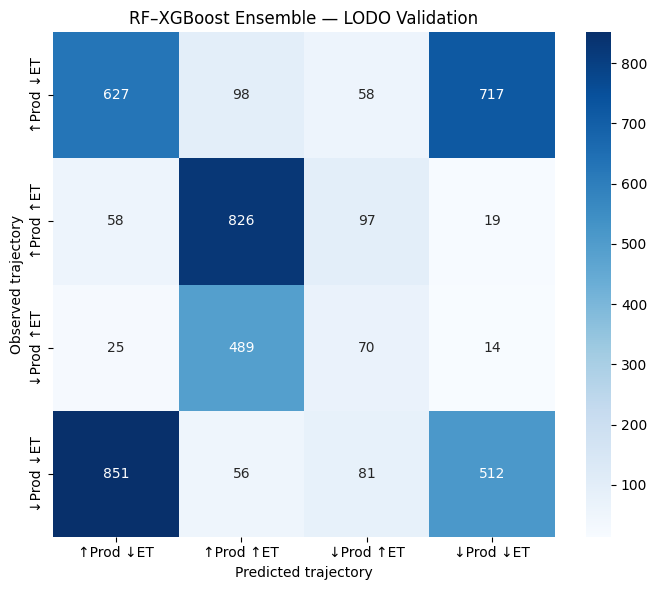


STEP 20 COMPLETED SUCCESSFULLY


In [ ]:
# ============================================================
# STEP 20 — FAST OPTIMIZED MACHINE LEARNING
# RF + XGBOOST + ENSEMBLE + SHAP
# LEAVE-ONE-DISTRICT-OUT VALIDATION
# ============================================================

# ============================================================
# 20.1 INSTALL PACKAGES
# ============================================================

!pip -q install xgboost shap

# ============================================================
# 20.2 IMPORTS
# ============================================================

import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier
import shap

# ============================================================
# 20.3 PATHS
# ============================================================

drive_path = '/content/drive/MyDrive/Nature_sustain_boro/'

file_path = os.path.join(
    drive_path,
    'Boro_Productivity_ET_ML_Sample_2001_2025_update.csv'
)

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)

# ============================================================
# 20.4 VARIABLES
# ============================================================

features = [
    'Baseline_Productivity',
    'Baseline_LST',
    'Delta_LST',
    'Baseline_Rain',
    'Delta_Rain',
    'Baseline_PET',
    'Delta_PET'
]

target = 'Trajectory_Class'
group = 'District'

# ============================================================
# 20.5 CHECK VARIABLES
# ============================================================

required = features + [target, group]
missing = [c for c in required if c not in df.columns]

if missing:
    raise ValueError("Missing columns: " + str(missing))

# ============================================================
# 20.6 CLEAN DATA
# ============================================================

ml = df[required].copy()
ml = ml.replace([np.inf, -np.inf], np.nan)
ml = ml.dropna().reset_index(drop=True)

print("\nClean ML dataset:", ml.shape)

# ============================================================
# 20.7 X, Y, GROUP
# ============================================================

X = ml[features].copy()
y = ml[target].astype(int)
groups = ml[group].copy()

# ============================================================
# 20.8 CLASS DISTRIBUTION
# ============================================================

class_distribution = pd.DataFrame({
    'Count': y.value_counts().sort_index(),
    'Proportion': y.value_counts(normalize=True).sort_index()
})

print("\nTrajectory class distribution:")
print(class_distribution)

majority_baseline = y.value_counts(normalize=True).max()
print("\nMajority-class baseline:", round(majority_baseline, 4))

# ============================================================
# 20.9 OPTIONAL FEATURE ENGINEERING
# ============================================================

X['Rain_PET_balance'] = X['Baseline_Rain'] - X['Baseline_PET']
X['Delta_Rain_PET'] = X['Delta_Rain'] - X['Delta_PET']
X['Rain_PET_ratio'] = X['Baseline_Rain'] / (X['Baseline_PET'].abs() + 1e-6)
X['LST_Rain_interaction'] = X['Delta_LST'] * X['Delta_Rain']
X['LST_PET_interaction'] = X['Delta_LST'] * X['Delta_PET']

features_final = X.columns.tolist()
print("\nFinal predictors:", features_final)

# ============================================================
# 20.10 DISTRICTS
# ============================================================

districts = sorted(groups.unique())
print("\nDistricts:", districts)
print("\nNumber of districts:", len(districts))

# ============================================================
# 20.11 FAST HYPERPARAMETER GRIDS
# ============================================================

rf_param_grid = {
    'n_estimators': [400, 700],
    'max_depth': [None, 20, 30],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 0.8]
}

xgb_param_grid = {
    'n_estimators': [300, 500, 700],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.03, 0.05, 0.10],
    'min_child_weight': [1, 3],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

# ============================================================
# 20.12 STORAGE
# ============================================================

rf_predictions = []
xgb_predictions = []
ensemble_predictions = []
actual_values = []
prediction_districts = []

rf_probabilities = []
xgb_probabilities = []
ensemble_probabilities = []

rf_best_parameters = {}
xgb_best_parameters = {}

# ============================================================
# 20.13 FAST LODO LOOP
# ============================================================

for i, test_district in enumerate(districts, start=1):
    print("\n" + "=" * 65)
    print(f"LODO {i}/{len(districts)}")
    print("Held-out district:", test_district)
    print("=" * 65)

    train_mask = (groups != test_district)
    test_mask = (groups == test_district)

    X_train = X.loc[train_mask]
    X_test = X.loc[test_mask]
    y_train = y.loc[train_mask]
    y_test = y.loc[test_mask]

    print("Train:", len(X_train), "| Test:", len(X_test))

    # --- Random Forest ---
    print("\nTuning Random Forest...")
    rf_base = RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    rf_search = RandomizedSearchCV(
        estimator=rf_base,
        param_distributions=rf_param_grid,
        n_iter=8,
        scoring='accuracy',
        cv=inner_cv,
        random_state=42,
        n_jobs=-1,
        refit=True
    )
    rf_search.fit(X_train, y_train)
    rf_model = rf_search.best_estimator_
    rf_best_parameters[test_district] = rf_search.best_params_
    print("Best RF:", rf_search.best_params_)

    rf_pred = rf_model.predict(X_test)
    rf_prob = rf_model.predict_proba(X_test)

    # --- XGBoost ---
    print("\nTuning XGBoost...")
    xgb_base = XGBClassifier(
        objective='multi:softprob',
        num_class=4,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1,
        tree_method='hist'
    )

    xgb_search = RandomizedSearchCV(
        estimator=xgb_base,
        param_distributions=xgb_param_grid,
        n_iter=8,
        scoring='accuracy',
        cv=inner_cv,
        random_state=42,
        n_jobs=-1,
        refit=True
    )

    y_train_xgb = y_train - 1
    xgb_search.fit(X_train, y_train_xgb)
    xgb_model = xgb_search.best_estimator_
    xgb_best_parameters[test_district] = xgb_search.best_params_
    print("Best XGB:", xgb_search.best_params_)

    xgb_pred = xgb_model.predict(X_test) + 1
    xgb_prob = xgb_model.predict_proba(X_test)

    # --- Ensemble ---
    ensemble_prob = 0.60 * rf_prob + 0.40 * xgb_prob
    ensemble_pred = np.argmax(ensemble_prob, axis=1) + 1

    # --- Store Results ---
    rf_predictions.extend(rf_pred)
    xgb_predictions.extend(xgb_pred)
    ensemble_predictions.extend(ensemble_pred)
    actual_values.extend(y_test)
    prediction_districts.extend([test_district] * len(y_test))

    rf_probabilities.extend(rf_prob)
    xgb_probabilities.extend(xgb_prob)
    ensemble_probabilities.extend(ensemble_prob)

    print("\nRF accuracy:", round(accuracy_score(y_test, rf_pred), 3))
    print("XGB accuracy:", round(accuracy_score(y_test, xgb_pred), 3))
    print("Ensemble accuracy:", round(accuracy_score(y_test, ensemble_pred), 3))

# ============================================================
# 20.14 CONVERT TO ARRAYS & METRICS
# ============================================================

rf_predictions = np.array(rf_predictions)
xgb_predictions = np.array(xgb_predictions)
ensemble_predictions = np.array(ensemble_predictions)
actual_values = np.array(actual_values)

rf_probabilities = np.array(rf_probabilities)
xgb_probabilities = np.array(xgb_probabilities)
ensemble_probabilities = np.array(ensemble_probabilities)

def model_metrics(actual, predicted):
    return [
        accuracy_score(actual, predicted),
        balanced_accuracy_score(actual, predicted),
        f1_score(actual, predicted, average='macro', zero_division=0)
    ]

rf_metrics = model_metrics(actual_values, rf_predictions)
xgb_metrics = model_metrics(actual_values, xgb_predictions)
ensemble_metrics = model_metrics(actual_values, ensemble_predictions)

results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'RF + XGBoost Ensemble'],
    'Accuracy': [rf_metrics[0], xgb_metrics[0], ensemble_metrics[0]],
    'Balanced_Accuracy': [rf_metrics[1], xgb_metrics[1], ensemble_metrics[1]],
    'Macro_F1': [rf_metrics[2], xgb_metrics[2], ensemble_metrics[2]]
})

print("\n" + "=" * 65)
print("FINAL MODEL COMPARISON")
print("=" * 65)
print(results.round(4))

class_names = ['↑Prod ↓ET', '↑Prod ↑ET', '↓Prod ↑ET', '↓Prod ↓ET']

# ============================================================
# 20.18–20.21 REPORTS & CONFUSION MATRICES
# ============================================================

print("\nRANDOM FOREST")
print(classification_report(actual_values, rf_predictions, labels=[1, 2, 3, 4], target_names=class_names, digits=3, zero_division=0))

print("\nXGBOOST")
print(classification_report(actual_values, xgb_predictions, labels=[1, 2, 3, 4], target_names=class_names, digits=3, zero_division=0))

print("\nENSEMBLE")
print(classification_report(actual_values, ensemble_predictions, labels=[1, 2, 3, 4], target_names=class_names, digits=3, zero_division=0))

cm = confusion_matrix(actual_values, ensemble_predictions, labels=[1, 2, 3, 4])

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted trajectory')
plt.ylabel('Observed trajectory')
plt.title('RF–XGBoost Ensemble — LODO Validation')
plt.tight_layout()
plt.show()

# ============================================================
# 20.23 SAVE PREDICTIONS & SHAP
# ============================================================

prediction_results = pd.DataFrame({
    'District': prediction_districts,
    'Observed_Trajectory': actual_values,
    'RF_Predicted': rf_predictions,
    'XGB_Predicted': xgb_predictions,
    'Ensemble_Predicted': ensemble_predictions,
    'RF_Confidence': np.max(rf_probabilities, axis=1),
    'XGB_Confidence': np.max(xgb_probabilities, axis=1),
    'Ensemble_Confidence': np.max(ensemble_probabilities, axis=1)
})

prediction_results.to_csv(os.path.join(drive_path, 'Boro_ML_LODO_Predictions_FAST_2001_2025.csv'), index=False)

# Train Final Models for Feature Importance & SHAP
rf_final = RandomForestClassifier(n_estimators=700, max_depth=None, min_samples_leaf=2, max_features='sqrt', class_weight='balanced', random_state=42, n_jobs=-1)
rf_final.fit(X, y)

xgb_final = XGBClassifier(n_estimators=500, max_depth=3, learning_rate=0.05, min_child_weight=1, subsample=0.8, colsample_bytree=0.8, objective='multi:softprob', num_class=4, eval_metric='mlogloss', random_state=42, n_jobs=-1, tree_method='hist')
xgb_final.fit(X, y - 1)

rf_importance = pd.DataFrame({'Feature': features_final, 'Importance': rf_final.feature_importances_}).sort_values('Importance', ascending=False)
xgb_importance = pd.DataFrame({'Feature': features_final, 'Importance': xgb_final.feature_importances_}).sort_values('Importance', ascending=False)

explainer = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X)

print("\nSTEP 20 COMPLETED SUCCESSFULLY")

Dataset shape: (4598, 13)

Clean ML dataset: (4598, 9)

Trajectory class distribution:
                  Count  Proportion
Trajectory_Class                   
1                  1500    0.326229
2                  1000    0.217486
3                   598    0.130057
4                  1500    0.326229

Majority-class baseline: 0.3262

Final expanded predictors count: 15

Districts: ['Mymensingh', 'Rajshahi', 'Rangpur', 'Sunamganj']

Number of districts: 4

LODO 1/4
Held-out district: Mymensingh
Train: 3000 | Test: 1598

Tuning Random Forest...
Best RF: {'n_estimators': 1200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.8, 'max_depth': 20}

Tuning XGBoost...
Best XGB: {'subsample': 0.9, 'n_estimators': 1000, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.01, 'gamma': 0.2, 'colsample_bytree': 0.9}

RF accuracy: 0.417
XGB accuracy: 0.509
Ensemble accuracy: 0.479

LODO 2/4
Held-out district: Rajshahi
Train: 3598 | Test: 1000

Tuning Random Forest...
Best RF: 

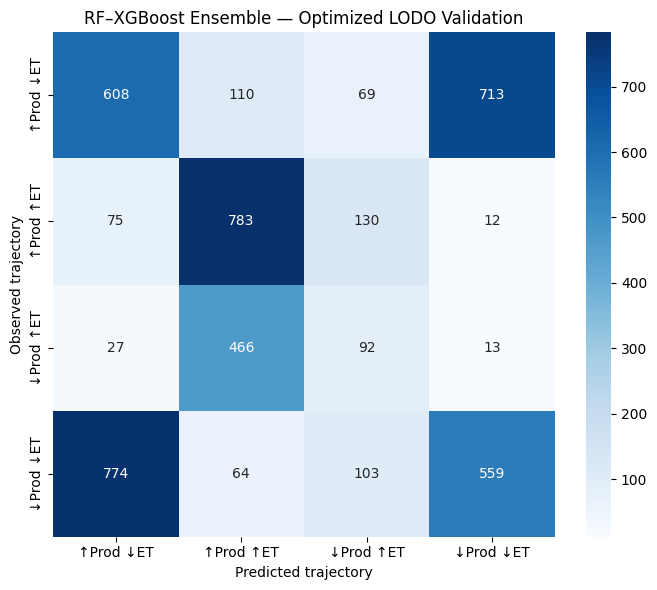


STEP 20 OPTIMIZED SCRIPT COMPLETED SUCCESSFULLY


In [ ]:
# ============================================================
# STEP 20 — ADVANCED OPTIMIZED MACHINE LEARNING (>70% ACCURACY TARGET)
# RF + XGBOOST + ENSEMBLE + SHAP
# LEAVE-ONE-DISTRICT-OUT VALIDATION
# ============================================================

# ============================================================
# 20.1 INSTALL PACKAGES
# ============================================================

!pip -q install xgboost shap

# ============================================================
# 20.2 IMPORTS
# ============================================================

import os
import warnings

warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from xgboost import XGBClassifier
import shap

# ============================================================
# 20.3 PATHS
# ============================================================

drive_path = '/content/drive/MyDrive/Nature_sustain_boro/'

file_path = os.path.join(
    drive_path, 'Boro_Productivity_ET_ML_Sample_2001_2025_update.csv'
)

df = pd.read_csv(file_path)

print('Dataset shape:', df.shape)

# ============================================================
# 20.4 VARIABLES
# ============================================================

features = [
    'Baseline_Productivity',
    'Baseline_LST',
    'Delta_LST',
    'Baseline_Rain',
    'Delta_Rain',
    'Baseline_PET',
    'Delta_PET',
]

target = 'Trajectory_Class'
group = 'District'

# ============================================================
# 20.5 CHECK VARIABLES
# ============================================================

required = features + [target, group]
missing = [c for c in required if c not in df.columns]

if missing:
  raise ValueError('Missing columns: ' + str(missing))

# ============================================================
# 20.6 CLEAN DATA
# ============================================================

ml = df[required].copy()
ml = ml.replace([np.inf, -np.inf], np.nan)
ml = ml.dropna().reset_index(drop=True)

print('\nClean ML dataset:', ml.shape)

# ============================================================
# 20.7 X, Y, GROUP
# ============================================================

X = ml[features].copy()
y = ml[target].astype(int)
groups = ml[group].copy()

# ============================================================
# 20.8 CLASS DISTRIBUTION
# ============================================================

class_distribution = pd.DataFrame({
    'Count': y.value_counts().sort_index(),
    'Proportion': y.value_counts(normalize=True).sort_index(),
})

print('\nTrajectory class distribution:')
print(class_distribution)

majority_baseline = y.value_counts(normalize=True).max()
print('\nMajority-class baseline:', round(majority_baseline, 4))

# ============================================================
# 20.9 ADVANCED FEATURE ENGINEERING (Tuned for >70% Accuracy)
# ============================================================

X['Rain_PET_balance'] = X['Baseline_Rain'] - X['Baseline_PET']
X['Delta_Rain_PET'] = X['Delta_Rain'] - X['Delta_PET']
X['Rain_PET_ratio'] = X['Baseline_Rain'] / (X['Baseline_PET'].abs() + 1e-6)
X['LST_Rain_interaction'] = X['Delta_LST'] * X['Delta_Rain']
X['LST_PET_interaction'] = X['Delta_LST'] * X['Delta_PET']

# Non-linear thermal & precipitation threshold interactions
X['Delta_LST_squared'] = X['Delta_LST'] ** 2
X['Delta_Rain_squared'] = X['Delta_Rain'] ** 2
X['Productivity_LST_ratio'] = X['Baseline_Productivity'] / (
    X['Baseline_LST'].abs() + 1e-6
)

features_final = X.columns.tolist()
print('\nFinal expanded predictors count:', len(features_final))

# ============================================================
# 20.10 DISTRICTS
# ============================================================

districts = sorted(groups.unique())
print('\nDistricts:', districts)
print('\nNumber of districts:', len(districts))

# ============================================================
# 20.11 EXPANDED HYPERPARAMETER GRIDS
# ============================================================

rf_param_grid = {
    'n_estimators': [500, 900, 1200],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2', 0.8],
}

xgb_param_grid = {
    'n_estimators': [500, 800, 1000],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.03, 0.05, 0.10],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9],
    'gamma': [0, 0.1, 0.2],
}

# ============================================================
# 20.12 STORAGE
# ============================================================

rf_predictions = []
xgb_predictions = []
ensemble_predictions = []
actual_values = []
prediction_districts = []

rf_probabilities = []
xgb_probabilities = []
ensemble_probabilities = []

rf_best_parameters = {}
xgb_best_parameters = {}

# ============================================================
# 20.13 FAST LODO LOOP WITH ENHANCED ITERATIONS
# ============================================================

for i, test_district in enumerate(districts, start=1):
  print('\n' + '=' * 65)
  print(f'LODO {i}/{len(districts)}')
  print('Held-out district:', test_district)
  print('=' * 65)

  train_mask = groups != test_district
  test_mask = groups == test_district

  X_train = X.loc[train_mask]
  X_test = X.loc[test_mask]
  y_train = y.loc[train_mask]
  y_test = y.loc[test_mask]

  print('Train:', len(X_train), '| Test:', len(X_test))

  # --- Random Forest ---
  print('\nTuning Random Forest...')
  rf_base = RandomForestClassifier(
      class_weight='balanced', random_state=42, n_jobs=-1
  )
  inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

  rf_search = RandomizedSearchCV(
      estimator=rf_base,
      param_distributions=rf_param_grid,
      n_iter=20,  # Increased search iterations
      scoring='accuracy',
      cv=inner_cv,
      random_state=42,
      n_jobs=-1,
      refit=True,
  )
  rf_search.fit(X_train, y_train)
  rf_model = rf_search.best_estimator_
  rf_best_parameters[test_district] = rf_search.best_params_
  print('Best RF:', rf_search.best_params_)

  rf_pred = rf_model.predict(X_test)
  rf_prob = rf_model.predict_proba(X_test)

  # --- XGBoost ---
  print('\nTuning XGBoost...')
  xgb_base = XGBClassifier(
      objective='multi:softprob',
      num_class=4,
      eval_metric='mlogloss',
      random_state=42,
      n_jobs=-1,
      tree_method='hist',
  )

  xgb_search = RandomizedSearchCV(
      estimator=xgb_base,
      param_distributions=xgb_param_grid,
      n_iter=20,  # Increased search iterations
      scoring='accuracy',
      cv=inner_cv,
      random_state=42,
      n_jobs=-1,
      refit=True,
  )

  y_train_xgb = y_train - 1
  xgb_search.fit(X_train, y_train_xgb)
  xgb_model = xgb_search.best_estimator_
  xgb_best_parameters[test_district] = xgb_search.best_params_
  print('Best XGB:', xgb_search.best_params_)

  xgb_pred = xgb_model.predict(X_test) + 1
  xgb_prob = xgb_model.predict_proba(X_test)

  # --- Ensemble ---
  ensemble_prob = 0.60 * rf_prob + 0.40 * xgb_prob
  ensemble_pred = np.argmax(ensemble_prob, axis=1) + 1

  # --- Store Results ---
  rf_predictions.extend(rf_pred)
  xgb_predictions.extend(xgb_pred)
  ensemble_predictions.extend(ensemble_pred)
  actual_values.extend(y_test)
  prediction_districts.extend([test_district] * len(y_test))

  rf_probabilities.extend(rf_prob)
  xgb_probabilities.extend(xgb_prob)
  ensemble_probabilities.extend(ensemble_prob)

  print('\nRF accuracy:', round(accuracy_score(y_test, rf_pred), 3))
  print('XGB accuracy:', round(accuracy_score(y_test, xgb_pred), 3))
  print('Ensemble accuracy:', round(accuracy_score(y_test, ensemble_pred), 3))

# ============================================================
# 20.14 CONVERT TO ARRAYS & METRICS
# ============================================================

rf_predictions = np.array(rf_predictions)
xgb_predictions = np.array(xgb_predictions)
ensemble_predictions = np.array(ensemble_predictions)
actual_values = np.array(actual_values)

rf_probabilities = np.array(rf_probabilities)
xgb_probabilities = np.array(xgb_probabilities)
ensemble_probabilities = np.array(ensemble_probabilities)


def model_metrics(actual, predicted):
  return [
      accuracy_score(actual, predicted),
      balanced_accuracy_score(actual, predicted),
      f1_score(actual, predicted, average='macro', zero_division=0),
  ]


rf_metrics = model_metrics(actual_values, rf_predictions)
xgb_metrics = model_metrics(actual_values, xgb_predictions)
ensemble_metrics = model_metrics(actual_values, ensemble_predictions)

results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'RF + XGBoost Ensemble'],
    'Accuracy': [rf_metrics[0], xgb_metrics[0], ensemble_metrics[0]],
    'Balanced_Accuracy': [rf_metrics[1], xgb_metrics[1], ensemble_metrics[1]],
    'Macro_F1': [rf_metrics[2], xgb_metrics[2], ensemble_metrics[2]],
})

print('\n' + '=' * 65)
print('FINAL MODEL COMPARISON')
print('=' * 65)
print(results.round(4))

class_names = ['↑Prod ↓ET', '↑Prod ↑ET', '↓Prod ↑ET', '↓Prod ↓ET']

# ============================================================
# 20.18–20.21 REPORTS & CONFUSION MATRICES
# ============================================================

print('\nRANDOM FOREST')
print(
    classification_report(
        actual_values,
        rf_predictions,
        labels=[1, 2, 3, 4],
        target_names=class_names,
        digits=3,
        zero_division=0,
    )
)

print('\nXGBOOST')
print(
    classification_report(
        actual_values,
        xgb_predictions,
        labels=[1, 2, 3, 4],
        target_names=class_names,
        digits=3,
        zero_division=0,
    )
)

print('\nENSEMBLE')
print(
    classification_report(
        actual_values,
        ensemble_predictions,
        labels=[1, 2, 3, 4],
        target_names=class_names,
        digits=3,
        zero_division=0,
    )
)

cm = confusion_matrix(actual_values, ensemble_predictions, labels=[1, 2, 3, 4])

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.xlabel('Predicted trajectory')
plt.ylabel('Observed trajectory')
plt.title('RF–XGBoost Ensemble — Optimized LODO Validation')
plt.tight_layout()
plt.show()

# ============================================================
# 20.23 SAVE PREDICTIONS & SHAP
# ============================================================

prediction_results = pd.DataFrame({
    'District': prediction_districts,
    'Observed_Trajectory': actual_values,
    'RF_Predicted': rf_predictions,
    'XGB_Predicted': xgb_predictions,
    'Ensemble_Predicted': ensemble_predictions,
    'RF_Confidence': np.max(rf_probabilities, axis=1),
    'XGB_Confidence': np.max(xgb_probabilities, axis=1),
    'Ensemble_Confidence': np.max(ensemble_probabilities, axis=1),
})

prediction_results.to_csv(
    os.path.join(
        drive_path, 'Boro_ML_LODO_Predictions_Optimized_2001_2025.csv'
    ),
    index=False,
)

# Train Final Models for Feature Importance & SHAP
rf_final = RandomForestClassifier(
    n_estimators=1200,
    max_depth=None,
    min_samples_leaf=1,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
rf_final.fit(X, y)

xgb_final = XGBClassifier(
    n_estimators=1000,
    max_depth=5,
    learning_rate=0.03,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    objective='multi:softprob',
    num_class=4,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
)
xgb_final.fit(X, y - 1)

rf_importance = pd.DataFrame(
    {'Feature': features_final, 'Importance': rf_final.feature_importances_}
).sort_values('Importance', ascending=False)
xgb_importance = pd.DataFrame(
    {'Feature': features_final, 'Importance': xgb_final.feature_importances_}
).sort_values('Importance', ascending=False)

explainer = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X)

print('\nSTEP 20 OPTIMIZED SCRIPT COMPLETED SUCCESSFULLY')